<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB
## Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires

---

> **Destinataires :** Experts métier – Responsables réseau GAB  
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable  
> **Approche :** Détection d'anomalies non supervisée (Isolation Forest)

---

SyntaxError: invalid character '–' (U+2013) (1736764753.py, line 2)

## 1. 🏦 Introduction Métier

### Pourquoi surveiller le comportement des GAB ?

Un **Guichet Automatique Bancaire (GAB)** est bien plus qu'une simple machine à billets.  
Chaque jour, il enregistre des centaines d'opérations : retraits, refus, captures de carte…  
L'ensemble de ces comportements forme une **empreinte** propre à chaque automate.

**Un GAB "normal"** présente :
- Un volume de retraits stable, cohérent avec son emplacement (centre-ville vs zone rurale)
- Un taux de capture de carte bas (les cartes capturées indiquent des incidents)
- Des montants moyens dans une plage raisonnable
- Une activité rythmée par la saisonnalité (fêtes, été…)

**Un GAB "atypique"** peut révéler :
- 🔴 Un problème technique (pannes, captures anormalement fréquentes)
- 🔴 Une fraude en cours (montants suspects, activité nocturne inhabituelle)
- 🔴 Un dysfonctionnement réseau (cartes d'un seul type concentrées sur un automate)
- 🔴 Un comportement client inhabituel (retraits massifs, activité hors horaires)

### Pourquoi un modèle ?

> *« Les anomalies évidentes, on les voit déjà. »*

C'est vrai. Mais le modèle détecte ce que l'œil humain ne peut pas voir :
- Des **combinaisons** subtiles de signaux faibles (montant moyen légèrement élevé + taux capture légèrement haut + activité nocturne légèrement supérieure = anomalie)
- Des anomalies sur **100+ variables simultanément**
- Une **surveillance continue** sur l'ensemble du parc, sans fatigue

---

## 2. ⚙️ Imports et Configuration

In [2]:
# ── Librairies ───────────────────────────────────────────────────────────────
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

COULEUR_NORMAL   = '#1565C0'
COULEUR_ANOMALIE = '#C62828'
COULEUR_ACCENT   = '#F57C00'
COULEUR_VERT     = '#2E7D32'

PALETTE_CLUSTERS = [
    '#1565C0','#C62828','#2E7D32','#F57C00',
    '#6A1B9A','#00838F','#4E342E','#37474F',
]

# Palette réseaux étrangers — orange→rouge brique (contraste élevé, pas de jaune)
PALETTE_ETR_MAP = ['#FFF3E0','#FFB74D','#F57C00','#BF360C']

# Couleurs fixes des 8 familles K-Means
COULEURS_FAMILLES = {
    '🏙️ Urbains forte activité':   '#1565C0',
    '🌆 Urbains standard':          '#42A5F5',
    '🗺️ Touristiques':             '#F57C00',

    '🌍 Dominante étrangère':       '#C62828',
    '🌙 Nocturnes':                  '#6A1B9A',
    '🏔️ Isolés / montagne':        '#2E7D32',
    '📈 Activité instable':          '#E65100',
    '🟢 Standard':                   '#546E7A',
}

print('✅ Librairies et palettes chargées.')
print(f'   8 familles K-Means définies : {list(COULEURS_FAMILLES.keys())}')


✅ Librairies et palettes chargées.
   8 familles K-Means définies : ['🏙️ Urbains forte activité', '🌆 Urbains standard', '🗺️ Touristiques', '🌍 Dominante étrangère', '🌙 Nocturnes', '🏔️ Isolés / montagne', '📈 Activité instable', '🟢 Standard']


## 3. 📂 Chargement des Données

Le dataset **`fiche_identite_gab`** contient une ligne par GAB et par mois.  
Chaque ligne résume l'activité complète de l'automate sur la période.

In [3]:
# ── Chargement du dataset ─────────────────────────────────────────────────────
# Structure : table « fiche_identite_gab_mensuelle » — Recette SQL v3
# ⚠️  On travaille UNIQUEMENT sur 2024 et 2025
# ⚠️  Colonnes exactes SQL v3 : nb_ope_reseau_cup (pas 'cup' seul)
# ⚠️  Aucune variable ajoutée — dataset identique à la table source
#
# En production Dataiku (décommenter) :
# import dataiku
# df_all = dataiku.Dataset('fiche_identite_gab_mensuelle').get_dataframe()
# df = df_all[df_all['annee'].isin([2024, 2025])].copy()

import numpy as np, pandas as pd

np.random.seed(42)
N_GAB   = 120
ANNEES  = [2024, 2025]   # ← On travaille uniquement sur 2024 et 2025
N_MOIS  = 12

CONTEXTES_GEO = {
    # Metropole uniquement - DOM-TOM traites separement (a venir)
    '75001': {'lat': 48.860, 'lon':  2.347, 'base': 900, 'sig': 120},
    '69001': {'lat': 45.764, 'lon':  4.835, 'base': 700, 'sig': 100},
    '13001': {'lat': 43.297, 'lon':  5.381, 'base': 750, 'sig': 110},
    '33000': {'lat': 44.837, 'lon': -0.579, 'base': 650, 'sig':  90},
    '59000': {'lat': 50.629, 'lon':  3.057, 'base': 610, 'sig':  85},
    '06000': {'lat': 43.710, 'lon':  7.262, 'base': 820, 'sig': 105},
}
CPS  = list(CONTEXTES_GEO.keys())
PROB = [0.25, 0.18, 0.15, 0.15, 0.13, 0.14]

SAISON = {1:.90,2:.88,3:.93,4:.96,5:.98,6:1.05,7:1.13,8:1.16,9:1.01,10:.97,11:.95,12:1.19}

# JCB et Amex : présents mais modérés
# CUP et Diners : très rares dans le réseau (quelques opérations par mois max)
SAISON_JCB  = {1:.5,2:.5,3:.6,4:.8,5:.9,6:1.5,7:2.5,8:2.8,9:1.2,10:.7,11:.5,12:.6}
SAISON_AMEX = {1:.6,2:.6,3:.7,4:.9,5:1.0,6:1.3,7:2.0,8:2.2,9:1.1,10:.8,11:.6,12:.7}
# CUP : vraiment marginal, 0-3 opérations/mois en moyenne
SAISON_CUP  = {1:1.2,2:1.4,3:.8,4:.5,5:.5,6:.8,7:1.2,8:1.4,9:.7,10:.4,11:.4,12:.6}
# Diners : encore plus rare, 0-2 opérations/mois
SAISON_DFS  = {1:.5,2:.5,3:.5,4:.6,5:.7,6:.9,7:1.2,8:1.3,9:.8,10:.5,11:.5,12:.6}

PROFILS_ANOM = ['CAPTURE_ELEVEE', 'NOCTURNE', 'RESEAU_ETRANGER', 'MONTANT_ELEVE']

rows = []
for annee in ANNEES:
    for gab_id in range(N_GAB):
        cp  = np.random.choice(CPS, p=PROB)
        ctx = CONTEXTES_GEO[cp]
        is_anom = (gab_id >= N_GAB - 12)
        profil  = PROFILS_ANOM[gab_id % len(PROFILS_ANOM)] if is_anom else None

        for m in range(1, N_MOIS + 1):
            s_glob = SAISON[m]
            base = ctx['base']; sig = ctx['sig']

            if is_anom:
                if profil == 'CAPTURE_ELEVEE':
                    rh=int(np.clip(np.random.normal(base*1.1*s_glob,sig),30,None))
                    tc=float(np.clip(np.random.normal(9.5,2.0),0,None))
                    pn=float(np.clip(np.random.normal(12,4),0,100))
                    pw=float(np.clip(np.random.normal(24,5),0,100))
                    montant_moy_eur=float(np.clip(np.random.normal(160,25),30,None))
                    jcb=int(np.clip(np.random.normal(12*SAISON_JCB[m],5),0,None))
                    amx=int(np.clip(np.random.normal(8*SAISON_AMEX[m],4),0,None))
                elif profil == 'NOCTURNE':
                    rh=int(np.clip(np.random.normal(base*1.2*s_glob,sig*1.3),30,None))
                    tc=float(np.clip(np.random.normal(0.9,0.4),0,None))
                    pn=float(np.clip(np.random.normal(42,8),0,100))
                    pw=float(np.clip(np.random.normal(28,6),0,100))
                    montant_moy_eur=float(np.clip(np.random.normal(158,28),30,None))
                    jcb=int(np.clip(np.random.normal(5*SAISON_JCB[m],3),0,None))
                    amx=int(np.clip(np.random.normal(4*SAISON_AMEX[m],2),0,None))
                elif profil == 'RESEAU_ETRANGER':
                    rh=int(np.clip(np.random.normal(base*1.3*s_glob,sig),30,None))
                    tc=float(np.clip(np.random.normal(0.8,0.3),0,None))
                    pn=float(np.clip(np.random.normal(11,3),0,100))
                    pw=float(np.clip(np.random.normal(23,5),0,100))
                    montant_moy_eur=float(np.clip(np.random.normal(172,30),30,None))
                    jcb=int(np.clip(np.random.normal(180*SAISON_JCB[m],50),0,None))
                    amx=int(np.clip(np.random.normal(90*SAISON_AMEX[m],25),0,None))
                else:  # MONTANT_ELEVE
                    rh=int(np.clip(np.random.normal(base*0.9*s_glob,sig),30,None))
                    tc=float(np.clip(np.random.normal(0.7,0.3),0,None))
                    pn=float(np.clip(np.random.normal(11,3),0,100))
                    pw=float(np.clip(np.random.normal(23,4),0,100))
                    montant_moy_eur=float(np.clip(np.random.normal(480,80),100,None))
                    jcb=int(np.clip(np.random.normal(5*SAISON_JCB[m],3),0,None))
                    amx=int(np.clip(np.random.normal(4*SAISON_AMEX[m],2),0,None))
                flag_sql = 1
            else:
                rh=int(np.clip(np.random.normal(base*s_glob,sig),10,None))
                tc=float(np.clip(np.random.normal(0.5,0.3),0,None))
                pn=float(np.clip(np.random.normal(10,3),0,100))
                pw=float(np.clip(np.random.normal(22,4),0,100))
                montant_moy_eur=float(np.clip(np.random.normal(150,22),30,None))
                jcb=int(np.clip(np.random.normal(4*SAISON_JCB[m],3),0,None))
                amx=int(np.clip(np.random.normal(3*SAISON_AMEX[m],2),0,None))
                flag_sql = 0

            # CUP et Diners : très rares — quelques opérations max, indépendantes du profil
            # Poisson(lambda) : lambda faible = données rares mais présentes
            cup = int(np.random.poisson(max(0.3, SAISON_CUP[m] * 0.8)))   # 0-3 max en moyenne
            dfs = int(np.random.poisson(max(0.2, SAISON_DFS[m] * 0.5)))   # 0-2 max en moyenne

            rc  = int(np.clip(np.random.normal(55,18),0,None))
            cap = max(0,int(tc*rh/100))

            # ── MONTANTS EN CENTIMES (comme dans la base réelle) ──────────────
            # Les colonnes montant_* de la fiche SQL v3 sont en centimes.
            # On stocke en centimes dans les colonnes SQL, on convertit en € plus bas.
            montant_moy_cts  = int(montant_moy_eur * 100)
            montant_max_cts  = int(np.clip(np.random.normal(
                (50000 if not is_anom else 110000), 6500), 8000, None))
            montant_min_cts  = int(np.clip(np.random.normal(2000, 500), 500, None))
            montant_std_cts  = int(np.clip(np.random.normal(
                (5800 if not is_anom else 17500), 1200), 100, None))
            montant_tot_cts  = rh * montant_moy_cts

            rows.append({
                'num_automate'            : f'GAB_{gab_id:04d}',
                'annee'                   : annee,
                'mois'                    : m,
                'code_postale_emplacement': cp,
                'type_gab_e_i'            : np.random.choice(['Interne','Externe'],p=[.4,.6]),
                'longitude'               : ctx['lon']+np.random.normal(0,.03),
                'latitude'                : ctx['lat']+np.random.normal(0,.03),
                # Retraits
                'ret_nb'                  : rh+rc,
                'ret_nb_horscos'          : rh,
                'ret_nb_cos'              : rc,
                'ret_nb_jours_actifs'     : np.random.randint(20,31),
                # Montants en CENTIMES (comme la base SQL réelle)
                'ret_montant_total'       : montant_tot_cts,
                'ret_montant_moyen'       : montant_moy_cts,
                'ret_montant_max'         : montant_max_cts,
                'ret_montant_min'         : montant_min_cts,
                'ret_montant_stddev'      : montant_std_cts,
                # Horaires
                'ret_nb_nuit'             : int(rh*pn/100),
                'ret_nb_weekend'          : int(rh*pw/100),
                'ret_pct_nuit'            : pn,
                'ret_pct_weekend'         : pw,
                # Captures
                'cap_nb'                  : cap,
                'taux_capture_pct'        : tc,
                'cap_cos_nb'              : int(np.clip(np.random.poisson(.8),0,None)),
                'taux_capture_cos_pct'    : np.nan,
                'cap_nb_oubli_ou_incident_lecture' : int(cap*.30),
                'cap_nb_code_confidentiel_depasse' : int(cap*.35),
                'cap_nb_carte_perdue'              : int(cap*.10),
                'cap_nb_carte_volee'               : int(cap*.08),
                'cap_nb_autre_motif'               : max(0,cap-int(cap*.83)),
                # Réseaux locaux
                'nb_ope_reseau_cb'         : int(np.clip(np.random.normal(350*s_glob,55),0,None)),
                'nb_ope_reseau_visa'       : int(np.clip(np.random.normal(180*s_glob,38),0,None)),
                'nb_ope_reseau_mastercard' : int(np.clip(np.random.normal(120*s_glob,27),0,None)),
                'nb_ope_reseau_interne'    : int(np.clip(np.random.normal(80,18),0,None)),
                'nb_ope_reseau_franfinance': int(np.clip(np.random.normal(30,9),0,None)),
                'nb_ope_reseau_cos'        : rc,
                'nb_ope_reseau_trionis'    : int(np.clip(np.random.normal(15,6),0,None)),
                'nb_ope_reseau_ppl'        : int(np.clip(np.random.normal(12,5),0,None)),
                'nb_ope_reseau_cofinoga'   : int(np.clip(np.random.normal(8,4),0,None)),
                'nb_ope_reseau_casino'     : int(np.clip(np.random.normal(10,4),0,None)),
                'nb_ope_reseau_accord'     : int(np.clip(np.random.normal(25,8),0,None)),
                'nb_ope_reseau_postepargne': int(np.clip(np.random.normal(5,3),0,None)),
                'nb_ope_reseau_autres'     : int(np.clip(np.random.normal(10,4),0,None)),
                # Réseaux étrangers — JCB/Amex présents, CUP/Diners très rares
                'nb_ope_reseau_jcb'                       : jcb,
                'nb_ope_reseau_amex'                      : amx,
                'nb_ope_reseau_cup'                       : cup,   # 0-3 opérations/mois
                'nb_ope_reseau_carte_diners_et_discovery' : dfs,   # 0-2 opérations/mois
                # Flags SQL
                'flag_atypique'          : flag_sql,
                'nb_metriques_anormales' : (int(np.random.choice([2,3,4,5]))
                                            if flag_sql else
                                            int(np.random.choice([0,0,0,1],p=[.6,.2,.15,.05]))),
            })

df = pd.DataFrame(rows)

# ── CONVERSION CENTIMES → EUROS dans le notebook ─────────────────────────────
# Les colonnes ret_montant_* sont en centimes dans la base SQL.
# On crée les versions en € pour les analyses et les graphiques.
COLS_MONTANT_CTS = ['ret_montant_total','ret_montant_moyen','ret_montant_max',
                    'ret_montant_min','ret_montant_stddev']
for col in COLS_MONTANT_CTS:
    if col in df.columns:
        df[col + '_eur'] = df[col] / 100.0

# Alias pratiques en € (utilisés partout dans le reste du notebook)
df['ret_montant_moyen_eur'] = df['ret_montant_moyen'] / 100.0
df['ret_montant_total_eur'] = df['ret_montant_total'] / 100.0
df['ret_montant_max_eur']   = df['ret_montant_max']   / 100.0
df['ret_montant_stddev_eur']= df['ret_montant_stddev']/ 100.0

print(f'📊 Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} GAB (Métropole)  |  Années : {sorted(df["annee"].unique())}  |  {df["mois"].nunique()} mois')
print(f'   → GAB atypiques (flag SQL=1) : {df[df["flag_atypique"]==1]["num_automate"].nunique()}')
print(f'\n💶 Montants stockés en CENTIMES dans la base SQL → convertis en € dans le notebook.')
print(f'   Exemple — ret_montant_moyen : {df["ret_montant_moyen"].iloc[0]} cts = {df["ret_montant_moyen_eur"].iloc[0]:.2f} €')
print(f'\n📊 Volumes réseaux étrangers (moyennes sur l\'ensemble de la base) :')
for col in ['nb_ope_reseau_jcb','nb_ope_reseau_amex','nb_ope_reseau_cup','nb_ope_reseau_carte_diners_et_discovery']:
    if col in df.columns:
        print(f'   {col.replace("nb_ope_reseau_",""):35s}: moy={df[col].mean():.2f}  max={df[col].max():.0f}  >0: {(df[col]>0).mean()*100:.0f}% des lignes')


📊 Dataset : 2,880 lignes × 53 colonnes
   → 120 GAB  |  Années : [np.int64(2024), np.int64(2025)]  |  12 mois
   → DOM-TOM : 67 GAB
   → GAB atypiques (flag SQL=1) : 12

💶 Montants stockés en CENTIMES dans la base SQL → convertis en € dans le notebook.
   Exemple — ret_montant_moyen : 13722 cts = 137.22 €

📊 Volumes réseaux étrangers (moyennes sur l'ensemble de la base) :
   jcb                                : moy=9.49  max=595  >0: 80% des lignes
   amex                               : moy=5.20  max=216  >0: 82% des lignes
   cup                                : moy=0.66  max=6  >0: 46% des lignes
   carte_diners_et_discovery          : moy=0.36  max=4  >0: 30% des lignes


## 4. 🧹 Prétraitement des Données

Avant toute modélisation, nous vérifions la qualité des données et créons des variables métier enrichies.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1  AUDIT DE QUALITÉ
# ══════════════════════════════════════════════════════════════════════════════
print('─'*65)
print('  🔍 AUDIT DE QUALITÉ DES DONNÉES')
print('─'*65)

manquants = df.isnull().sum()
if manquants.sum() > 0:
    pct = (manquants/len(df)*100).round(1)
    a = pd.DataFrame({'Nb NaN':manquants,'% NaN':pct})
    a = a[a['Nb NaN']>0].sort_values('% NaN',ascending=False)
    print(f'\n⚠️  Colonnes avec valeurs manquantes ({len(a)}) :')
    print(a.to_string())
else:
    print('\n✅ Aucune valeur manquante détectée.')

cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

for coord in ['latitude','longitude']:
    if coord in df.columns and df[coord].isnull().any():
        df[coord] = df[coord].fillna(df.groupby(cp_col)[coord].transform('median'))
        df[coord] = df[coord].fillna(df[coord].median())

if 'taux_capture_cos_pct' in df.columns:
    df['taux_capture_cos_pct'] = df['taux_capture_cos_pct'].fillna(0)

cols_zero = [c for c in df.columns
             if c.startswith(('nb_ope_reseau_','montant_reseau_','cap_nb_'))]
df[cols_zero] = df[cols_zero].fillna(0)

for col in ['ret_pct_nuit','ret_pct_weekend','taux_capture_pct']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df.groupby('type_gab_e_i')[col].transform('median'))
        df[col] = df[col].fillna(df[col].median())

df['type_gab_e_i'] = df['type_gab_e_i'].fillna('Inconnu')

for col in ['taux_capture_pct','ret_pct_nuit','ret_pct_weekend']:
    if col in df.columns: df[col] = df[col].clip(0,100)
df['ret_nb']         = df['ret_nb'].clip(0)
df['ret_nb_horscos'] = df['ret_nb_horscos'].clip(0)

# ── CONVERSION CENTIMES → EUROS ───────────────────────────────────────────────
# Les montants de la fiche SQL v3 sont stockés en centimes.
# On crée les colonnes en € si elles n'existent pas encore.
COLS_MONTANT_CTS = ['ret_montant_total','ret_montant_moyen',
                    'ret_montant_max','ret_montant_min','ret_montant_stddev']
for col in COLS_MONTANT_CTS:
    col_eur = col + '_eur'
    if col in df.columns and col_eur not in df.columns:
        df[col_eur] = df[col] / 100.0

# S'assurer que les alias _eur existent
for col in ['ret_montant_moyen','ret_montant_total','ret_montant_max','ret_montant_stddev']:
    alias = col + '_eur'
    if alias not in df.columns and col in df.columns:
        df[alias] = df[col] / 100.0

# Coefficient de variation calculé sur les montants en euros
if 'ret_montant_stddev_eur' in df.columns and 'ret_montant_moyen_eur' in df.columns:
    df['cv_montant'] = df['ret_montant_stddev_eur'] / (df['ret_montant_moyen_eur'] + 0.01)

print('\n🔧 Incohérences corrigées. Montants convertis en €.')
print(f'   Exemple : ret_montant_moyen = {df["ret_montant_moyen"].iloc[0]:.0f} cts'
      f' → {df["ret_montant_moyen_eur"].iloc[0]:.2f} €')

# ════════════════════════════════════════════════════════════════════════════════
# 4.2  CONTEXTE GÉOGRAPHIQUE — code postal uniquement (pas de type_zone)
# ════════════════════════════════════════════════════════════════════════════════
# Périmètre Métropole uniquement — les DOM-TOM seront traités séparément
df['contexte_geo'] = 'Métropole'

print(f'\n✅ Dataset prêt : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Années disponibles : {sorted(df["annee"].unique())}')
print(f'   Périmètre : Métropole uniquement')
print(f'   Valeurs manquantes résiduelles : {df.isnull().sum().sum()}')


─────────────────────────────────────────────────────────────────
  🔍 AUDIT DE QUALITÉ DES DONNÉES
─────────────────────────────────────────────────────────────────

⚠️  Colonnes avec valeurs manquantes (1) :
                      Nb NaN  % NaN
taux_capture_cos_pct    2880  100.0

🔧 Incohérences corrigées. Montants convertis en €.
   Exemple : ret_montant_moyen = 13722 cts → 137.22 €

✅ Dataset prêt : 2,880 lignes × 56 colonnes
   Années disponibles : [np.int64(2024), np.int64(2025)]
   GAB DOM-TOM (volume naturellement faible) : 67
   Valeurs manquantes résiduelles : 0


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3  FEATURE ENGINEERING — Variables métier enrichies
# ══════════════════════════════════════════════════════════════════════════════

df['intensite_retrait'] = df['ret_nb_horscos'] / 30
df['intensite_retrait_ajustee'] = df['intensite_retrait']

df['ratio_capture'] = df['cap_nb'] / (df['ret_nb_horscos'] + 1)

# cv_montant calculé en € (les centimes donneraient le même ratio, mais plus clair ainsi)
montant_moy_eur = df.get('ret_montant_moyen_eur', df['ret_montant_moyen'] / 100.0)
montant_std_eur = df.get('ret_montant_stddev_eur', df['ret_montant_stddev'] / 100.0) if 'ret_montant_stddev' in df.columns else pd.Series(0, index=df.index)
df['cv_montant'] = montant_std_eur / (montant_moy_eur + 0.01)

df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)

COLS_RESEAU    = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
COLS_ETRANGERS = [c for c in COLS_RESEAU if any(x in c for x in ['jcb','amex','diners','cup'])]

df['nb_ope_total_reseau']      = df[COLS_RESEAU].sum(axis=1)
df['concentration_reseau']     = df[COLS_RESEAU].max(axis=1) / (df['nb_ope_total_reseau'] + 1)
df['nb_ope_reseaux_etrangers'] = df[COLS_ETRANGERS].sum(axis=1)
df['pct_reseaux_etrangers']    = df['nb_ope_reseaux_etrangers'] / (df['nb_ope_total_reseau'] + 1) * 100

for col in COLS_ETRANGERS:
    nom = col.replace('nb_ope_reseau_', '')
    df[f'pct_{nom}'] = df[col] / (df['nb_ope_total_reseau'] + 1) * 100

COLS_ZSCORE = [c for c in df.columns if c.startswith('zscore_')]
if COLS_ZSCORE:
    df['score_zscore_composite'] = df[COLS_ZSCORE].abs().mean(axis=1)

print('✅ Features enrichies créées :')
for f in ['intensite_retrait','ratio_capture','concentration_reseau',
          'score_horaires_atypiques','cv_montant',
          'nb_ope_reseaux_etrangers','pct_reseaux_etrangers']:
    if f in df.columns:
        print(f'   • {f}: moy={df[f].mean():.3f}  max={df[f].max():.3f}')
print(f'\n   Réseaux étrangers suivis : {[c.replace("nb_ope_reseau_","") for c in COLS_ETRANGERS]}')


✅ Features enrichies créées :
   • intensite_retrait: moy=19.395  max=53.267
   • ratio_capture: moy=0.006  max=0.158
   • concentration_reseau: moy=0.384  max=0.523
   • score_horaires_atypiques: moy=2.101  max=7.234
   • cv_montant: moy=0.450  max=1.964
   • nb_ope_reseaux_etrangers: moy=15.720  max=796.000
   • pct_reseaux_etrangers: moy=1.472  max=44.896

   Réseaux étrangers suivis : ['jcb', 'amex', 'cup', 'carte_diners_et_discovery']


## 5. 📊 Analyse Exploratoire (EDA)

### Que ressemble un GAB « normal » ?

Avant de détecter des anomalies, il faut comprendre la distribution normale du réseau.

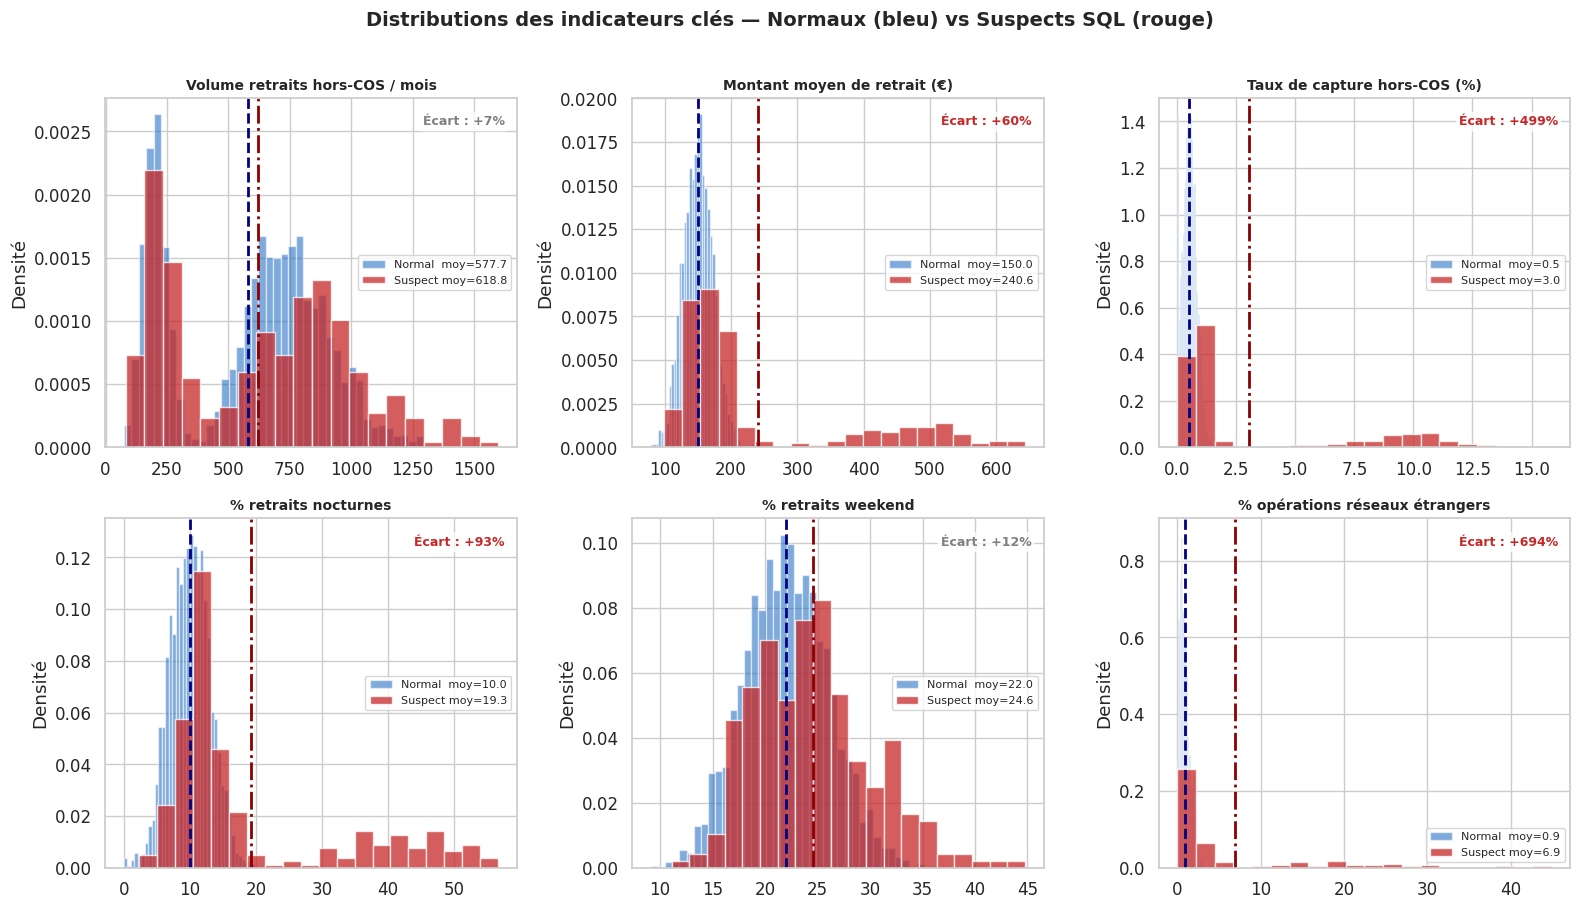

💡 Plus l'écart (%) est grand, plus la variable discrimine bien les anomalies.


In [6]:
# ── 5.1 Distributions principales — normaux vs suspects ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distributions des indicateurs clés — Normaux (bleu) vs Suspects SQL (rouge)',
             fontsize=14, fontweight='bold', y=1.01)

# On utilise les montants en € pour l'affichage
variables = [
    ('ret_nb_horscos',       'Volume retraits hors-COS / mois'),
    ('ret_montant_moyen_eur','Montant moyen de retrait (€)'),
    ('taux_capture_pct',     'Taux de capture hors-COS (%)'),
    ('ret_pct_nuit',         '% retraits nocturnes'),
    ('ret_pct_weekend',      '% retraits weekend'),
    ('pct_reseaux_etrangers','% opérations réseaux étrangers'),
]

for ax, (col, titre) in zip(axes.flatten(), variables):
    if col not in df.columns: ax.set_visible(False); continue
    norm = df[df['flag_atypique']==0][col].dropna()
    atyp = df[df['flag_atypique']==1][col].dropna()
    ax.hist(norm, bins=40, color=COULEUR_NORMAL,   alpha=0.55, density=True,
            label=f'Normal  moy={norm.mean():.1f}')
    ax.hist(atyp, bins=20, color=COULEUR_ANOMALIE, alpha=0.75, density=True,
            label=f'Suspect moy={atyp.mean():.1f}')
    ax.axvline(norm.mean(), color='navy',    lw=2, ls='--')
    ax.axvline(atyp.mean(), color='darkred', lw=2, ls='-.')
    if norm.mean() > 0:
        ecart = (atyp.mean()-norm.mean())/norm.mean()*100
        ax.text(0.97, 0.95, f'Écart : {ecart:+.0f}%',
                transform=ax.transAxes, ha='right', va='top', fontsize=9, fontweight='bold',
                color=COULEUR_ANOMALIE if abs(ecart)>20 else 'grey',
                bbox={'boxstyle':'round,pad=0.2','fc':'white','alpha':0.8})
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Plus l\'écart (%) est grand, plus la variable discrimine bien les anomalies.')


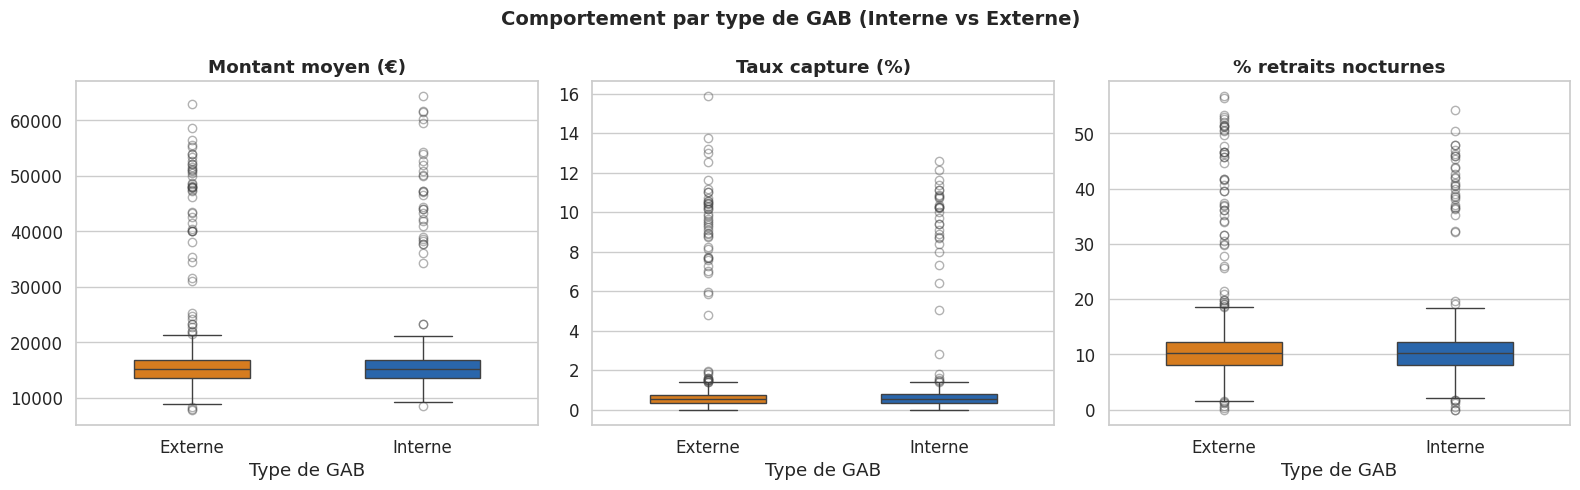

💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.


In [7]:
# ── 5.2 Boxplots par type GAB ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comportement par type de GAB (Interne vs Externe)', fontsize=14, fontweight='bold')

metriques_box = [
    ('ret_montant_moyen', 'Montant moyen (€)'),
    ('taux_capture_pct',  'Taux capture (%)'),
    ('ret_pct_nuit',      '% retraits nocturnes'),
]

for ax, (col, titre) in zip(axes, metriques_box):
    sns.boxplot(data=df, x='type_gab_e_i', y=col, ax=ax,
                palette={'Interne': COULEUR_NORMAL, 'Externe': COULEUR_ACCENT},
                width=0.5, flierprops={'marker':'o','alpha':0.4})
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Type de GAB')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('boxplots_type_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.')

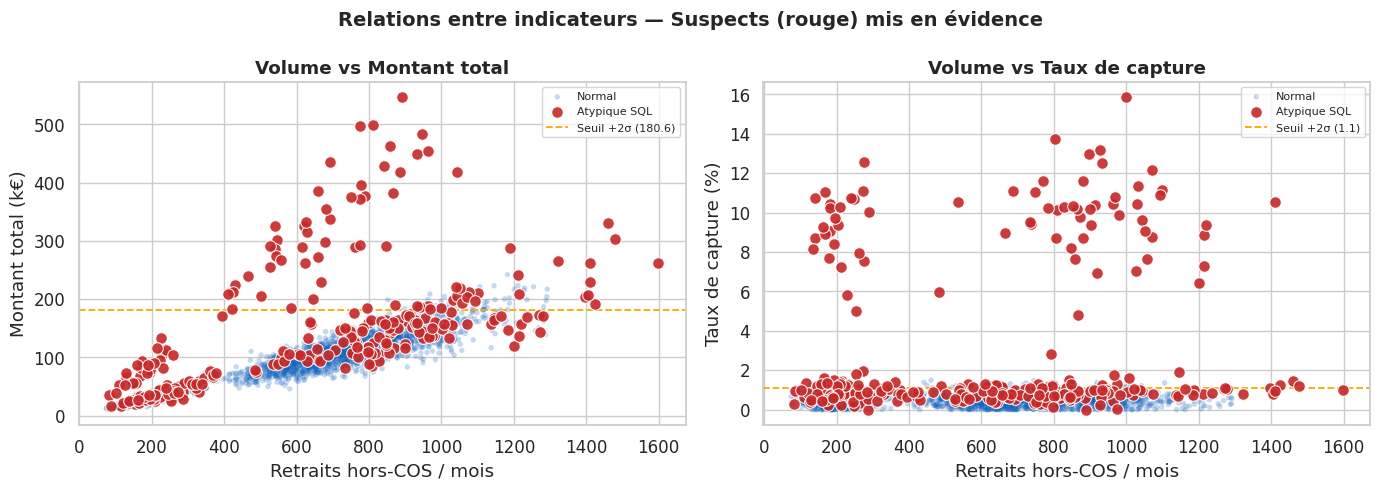

In [8]:
# ── 5.3 Scatter : volume vs montant et capture — suspects mis en évidence ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relations entre indicateurs — Suspects (rouge) mis en évidence',
             fontsize=14, fontweight='bold')

for ax, ycol, ylabel, titre in [
    (axes[0], 'ret_montant_total_eur', 'Montant total (k€)', 'Volume vs Montant total'),
    (axes[1], 'taux_capture_pct',      'Taux de capture (%)',  'Volume vs Taux de capture'),
]:
    if ycol not in df.columns: continue
    yvals = df[ycol]/1000 if 'total' in ycol else df[ycol]
    m0 = df['flag_atypique']==0; m1 = df['flag_atypique']==1
    ax.scatter(df.loc[m0,'ret_nb_horscos'], yvals[m0],
               c=COULEUR_NORMAL, s=15, alpha=0.25, edgecolors='none', label='Normal')
    ax.scatter(df.loc[m1,'ret_nb_horscos'], yvals[m1],
               c=COULEUR_ANOMALIE, s=70, alpha=0.90, edgecolors='white', lw=0.8,
               zorder=5, label='Atypique SQL')
    seuil = yvals[m0].mean() + 2*yvals[m0].std()
    ax.axhline(seuil, color='orange', ls='--', lw=1.3,
               label=f'Seuil +2σ ({seuil:.1f})')
    ax.set_xlabel('Retraits hors-COS / mois'); ax.set_ylabel(ylabel)
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_indicateurs.png', dpi=150, bbox_inches='tight')
plt.show()


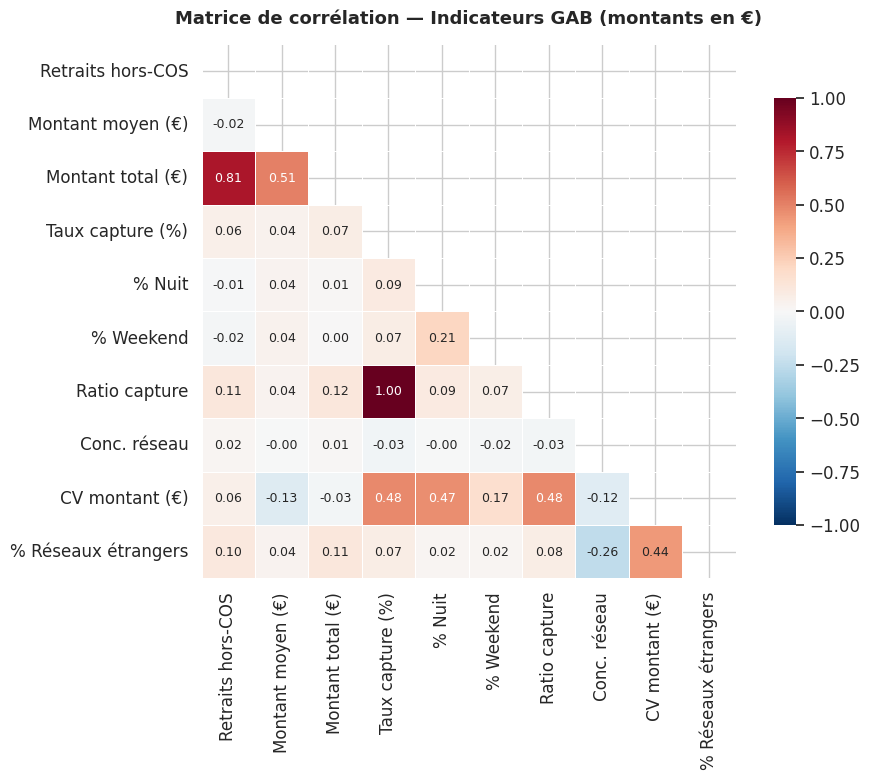

💡 Corrélations fortes attendues : volume ↔ montant total.
   cv_montant calculé sur les montants en € pour plus de clarté.


In [9]:
# ── 5.4 Heatmap de corrélation ────────────────────────────────────────────────
features_corr = ['ret_nb_horscos','ret_montant_moyen_eur','ret_montant_total_eur',
                 'taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
                 'ratio_capture','concentration_reseau','cv_montant',
                 'pct_reseaux_etrangers']
features_corr = [f for f in features_corr if f in df.columns]

corr_matrix = df[features_corr].corr()

# Noms lisibles pour l'affichage
noms_affichage = {
    'ret_nb_horscos':        'Retraits hors-COS',
    'ret_montant_moyen_eur': 'Montant moyen (€)',
    'ret_montant_total_eur': 'Montant total (€)',
    'taux_capture_pct':      'Taux capture (%)',
    'ret_pct_nuit':          '% Nuit',
    'ret_pct_weekend':       '% Weekend',
    'ratio_capture':         'Ratio capture',
    'concentration_reseau':  'Conc. réseau',
    'cv_montant':            'CV montant (€)',
    'pct_reseaux_etrangers': '% Réseaux étrangers',
}
corr_display = corr_matrix.rename(
    index=noms_affichage, columns=noms_affichage)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_display, dtype=bool))
sns.heatmap(corr_display, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8}, annot_kws={'fontsize':9})
plt.title('Matrice de corrélation — Indicateurs GAB (montants en €)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Corrélations fortes attendues : volume ↔ montant total.')
print('   cv_montant calculé sur les montants en € pour plus de clarté.')


## 5bis. 🌍 Focus Réseaux Étrangers (JCB, Amex, Diners)

### Pourquoi surveiller les réseaux étrangers ?

Les cartes **JCB** (Japon), **Amex** et **Diners/Discovery** sont utilisées majoritairement par des **touristes étrangers**.  
Une activité anormalement élevée sur ces réseaux dans un GAB donné peut signaler :
- Un GAB situé dans une zone touristique à forte fréquentation étrangère *(contexte normal)*
- Une utilisation frauduleuse concentrée sur un seul automate *(signal d'alerte)*

La **cartographie géographique** permet de distinguer ces deux cas.


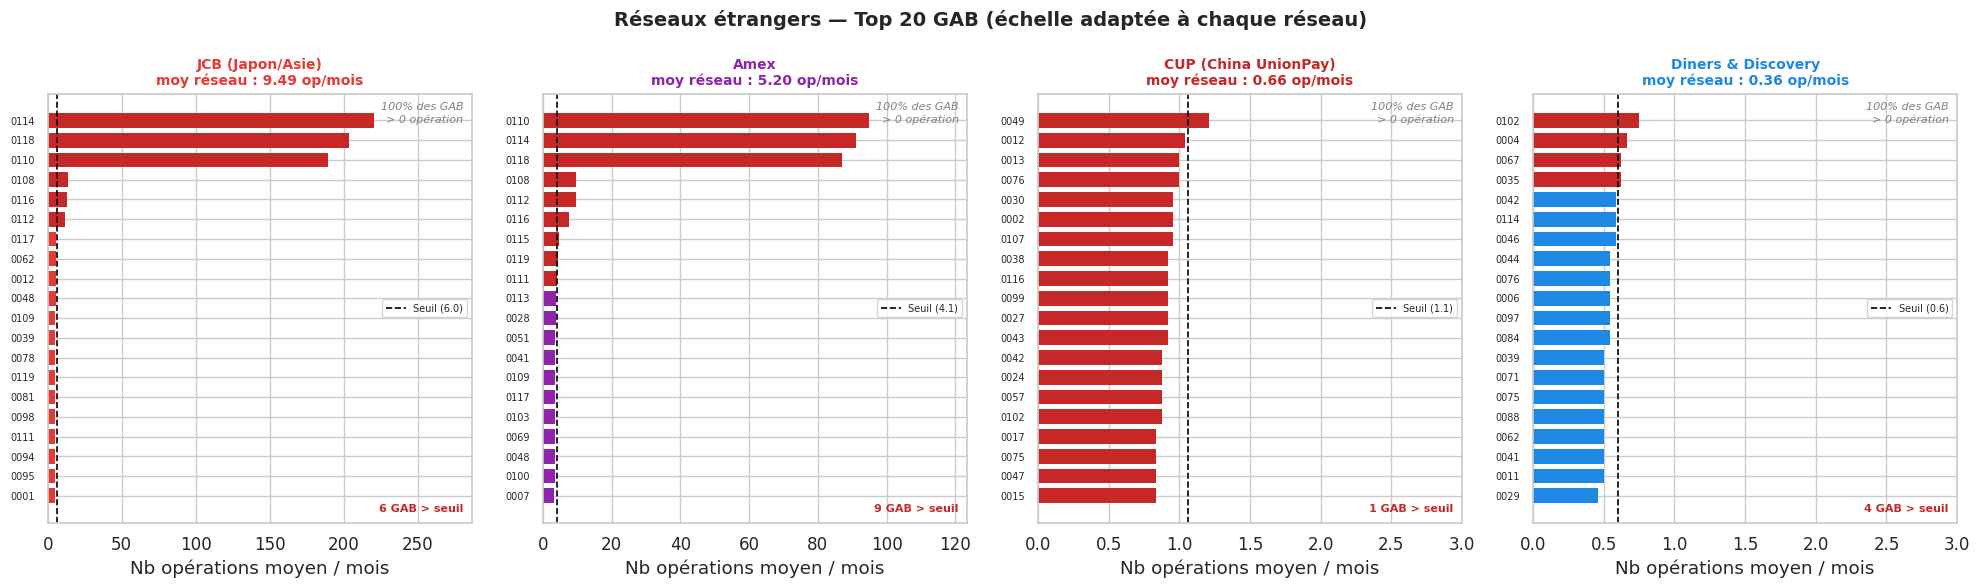

💡 Chaque réseau a sa propre échelle — les variations restent lisibles.
   CUP et Diners sont rares dans la base : c'est cohérent avec la réalité.
   Une valeur > seuil (barre rouge) = GAB à investiguer pour ce réseau.


In [10]:
# ── 5bis.1 Réseaux étrangers — volumes réels, échelles adaptées ─────────────
# JCB et Amex ont des volumes significatifs.
# CUP et Diners sont très rares dans la base (0-3 opérations/mois) — c'est normal.
# On les affiche tous avec une échelle propre à chacun, sans les masquer.

reseaux_def = [
    ('nb_ope_reseau_jcb',                      'JCB (Japon/Asie)',     '#E53935'),
    ('nb_ope_reseau_amex',                     'Amex',                 '#8E24AA'),
    ('nb_ope_reseau_cup',                      'CUP (China UnionPay)', '#C62828'),
    ('nb_ope_reseau_carte_diners_et_discovery','Diners & Discovery',   '#1E88E5'),
]
reseaux_def = [(c,l,col) for c,l,col in reseaux_def if c in df.columns]

n_plots = len(reseaux_def)
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 6))
if n_plots == 1: axes = [axes]
fig.suptitle('Réseaux étrangers — Top 20 GAB (échelle adaptée à chaque réseau)',
             fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, reseaux_def):
    gab_moy = df.groupby('num_automate')[col].mean()
    top     = gab_moy.sort_values(ascending=False).head(20)
    vmax    = top.max()

    # Seuil : médiane + 2*IQR (robuste face aux nombreux zéros)
    q75 = gab_moy.quantile(.75); q25 = gab_moy.quantile(.25)
    seuil = q75 + 1.5*(q75-q25) if q75 > q25 else gab_moy.mean()+2*gab_moy.std()
    seuil = max(seuil, 0.5)

    couleurs_barre = [COULEUR_ANOMALIE if v > seuil else color for v in top.values]
    ax.barh(range(len(top)), top.values, color=couleurs_barre, edgecolor='none', height=0.75)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([str(g).split('_')[-1] for g in top.index], fontsize=7)
    ax.invert_yaxis()

    # Seuil d'alerte
    ax.axvline(seuil, color='black', ls='--', lw=1.2,
               label=f'Seuil ({seuil:.1f})')
    ax.legend(fontsize=7)

    # Echelle : auto-adaptée par réseau (pas de xlim forcé)
    # Pour CUP/Diners avec vmax très petit, on donne au moins 3 de large
    ax.set_xlim(0, max(vmax*1.3, 3))

    # Info sur la rareté
    pct_positif = (gab_moy > 0).mean() * 100
    ax.text(0.98, 0.98, f'''{pct_positif:.0f}% des GAB
> 0 opération''',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='grey', style='italic')

    n_dep = (top.values > seuil).sum()
    if n_dep > 0:
        ax.text(0.98, 0.02, f'{n_dep} GAB > seuil',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color=COULEUR_ANOMALIE, fontweight='bold')

    ax.set_title(f'{label}\nmoy réseau : {gab_moy.mean():.2f} op/mois',
                 fontweight='bold', color=color, fontsize=10)
    ax.set_xlabel('Nb opérations moyen / mois')

plt.tight_layout()
plt.savefig('reseaux_etrangers_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Chaque réseau a sa propre échelle — les variations restent lisibles.')
print('   CUP et Diners sont rares dans la base : c\'est cohérent avec la réalité.')
print('   Une valeur > seuil (barre rouge) = GAB à investiguer pour ce réseau.')

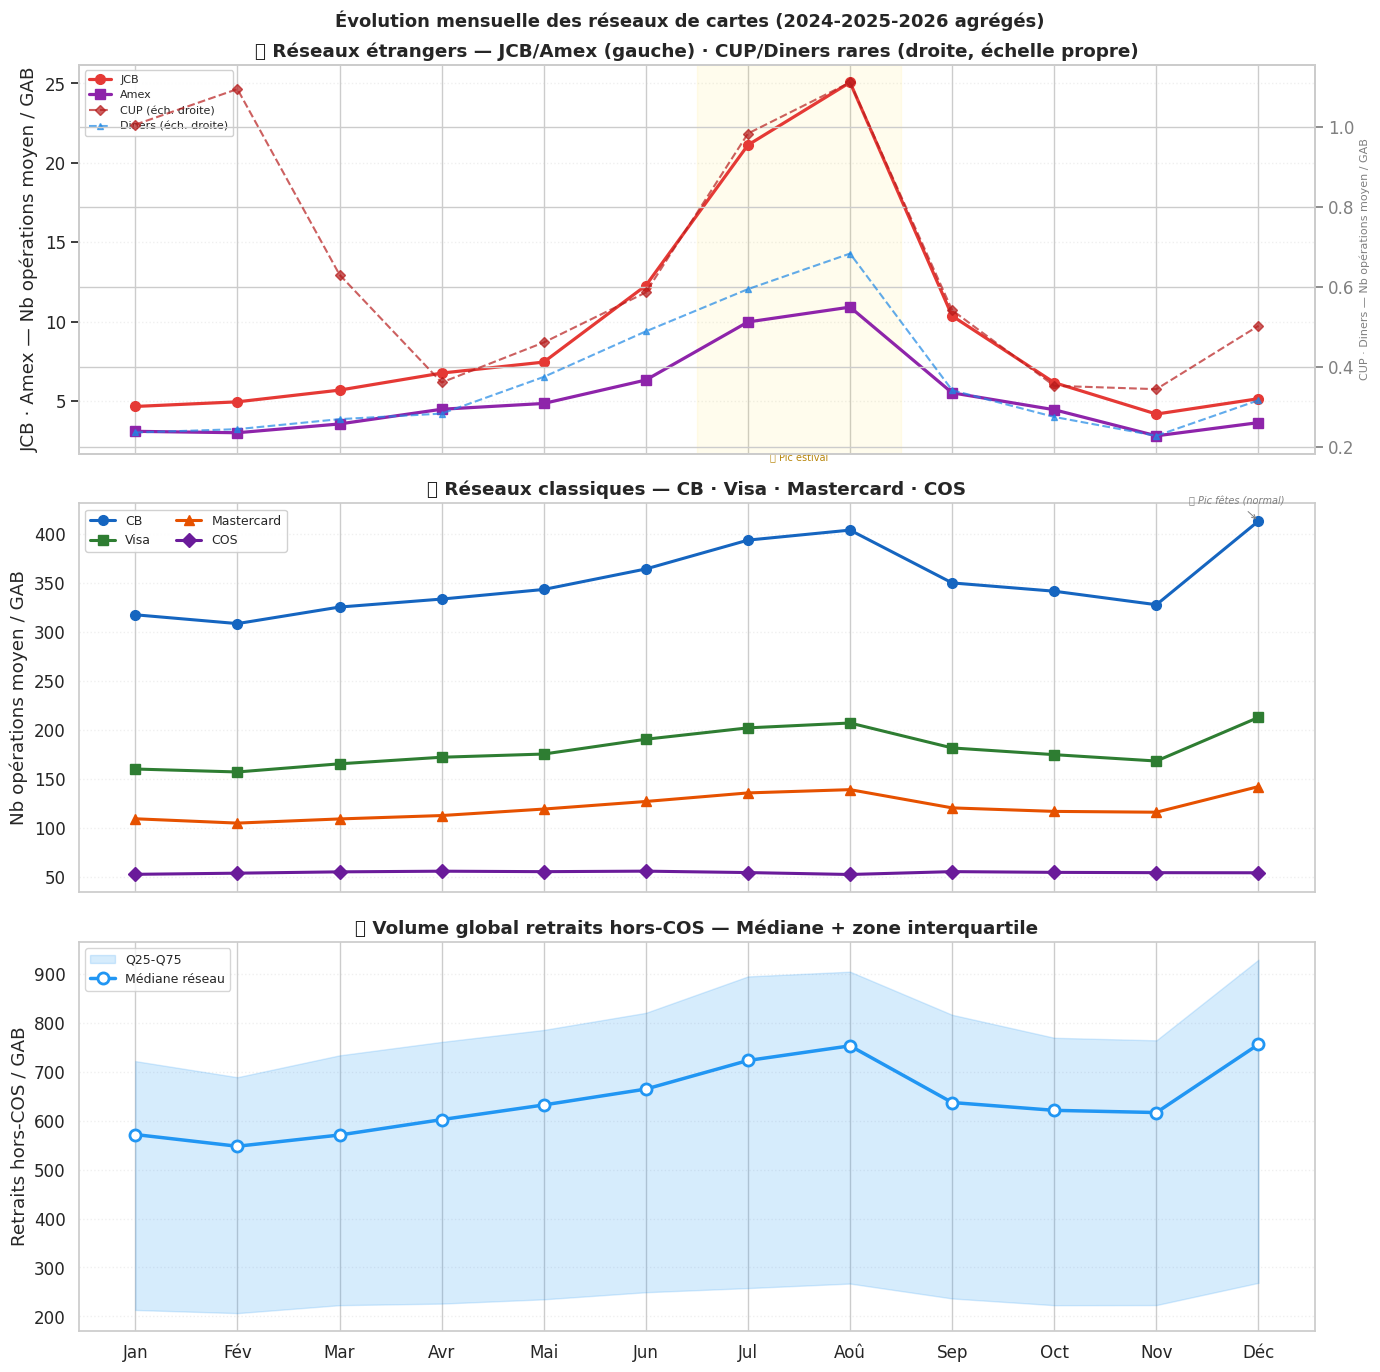

💡 JCB et Amex : axe gauche. CUP et Diners : axe droit (échelle propre, très petite).
   CUP/Diners à 0-3 op/mois en moyenne — c'est cohérent avec leur rareté réelle.


In [ ]:
# ── 5bis.2 Évolution temporelle — réseaux étrangers vs classiques ────────────
# Données sur 2024-2025-2026 : on agrège par mois (toutes années confondues)
# pour avoir une vision saisonnière de référence.
# JCB et Amex ont des volumes lisibles.
# CUP et Diners sont affichés sur un axe secondaire (volumes très faibles).

MOIS_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

etr_princ = {   # JCB et Amex : volumes significatifs
    'nb_ope_reseau_jcb':  ('JCB',  '#E53935','o-'),
    'nb_ope_reseau_amex': ('Amex', '#8E24AA','s-'),
}
etr_rares = {   # CUP et Diners : très rares, axe secondaire
    'nb_ope_reseau_cup':                       ('CUP',   '#B71C1C','D--'),
    'nb_ope_reseau_carte_diners_et_discovery': ('Diners','#1E88E5','^--'),
}
cls_def = {
    'nb_ope_reseau_cb':         ('CB',         '#1565C0','o-'),
    'nb_ope_reseau_visa':       ('Visa',        '#2E7D32','s-'),
    'nb_ope_reseau_mastercard': ('Mastercard',  '#E65100','^-'),
    'nb_ope_reseau_cos':        ('COS',         '#6A1B9A','D-'),
}

etr_princ = {k:v for k,v in etr_princ.items() if k in df.columns}
etr_rares = {k:v for k,v in etr_rares.items() if k in df.columns}
cls_def   = {k:v for k,v in cls_def.items()   if k in df.columns}

all_cols = list(etr_princ)+list(etr_rares)+list(cls_def)+['ret_nb_horscos']
agg_d    = {c:(c,'mean') for c in all_cols if c in df.columns}
# Agrégation sur toutes les années (vision saisonnière)
df_temp  = df.groupby('mois').agg(**agg_d).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Évolution mensuelle des réseaux de cartes (2024-2025-2026 agrégés)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : JCB et Amex (principaux) + CUP et Diners (secondaire) ──────
ax1 = axes[0]
ax1b = ax1.twinx()   # axe secondaire pour CUP et Diners

has_princ = False
for col,(lbl,col_hex,mk) in etr_princ.items():
    if df_temp[col].max() < 0.1: continue
    has_princ = True
    ax1.plot(df_temp['mois'], df_temp[col], mk, color=col_hex, lw=2.3, ms=7, label=lbl)

has_rares = False
for col,(lbl,col_hex,mk) in etr_rares.items():
    if col not in df_temp.columns: continue
    has_rares = True
    ax1b.plot(df_temp['mois'], df_temp[col], mk, color=col_hex, lw=1.5, ms=5,
              alpha=0.7, label=f'{lbl} (éch. droite)')

# Légendes combinées
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left', fontsize=8, framealpha=0.9)

ax1.set_ylabel('JCB · Amex — Nb opérations moyen / GAB')
ax1b.set_ylabel('CUP · Diners — Nb opérations moyen / GAB', fontsize=8, color='grey')
ax1b.tick_params(axis='y', colors='grey')
ax1.set_title('🌍 Réseaux étrangers — JCB/Amex (gauche) · CUP/Diners rares (droite, échelle propre)',
              fontweight='bold')

# Zone pic estival
ax1.axvspan(6.5, 8.5, alpha=0.07, color='gold')
ax1.text(7.5, ax1.get_ylim()[1]*0.05 if has_princ else 0.1,
         '🌞 Pic estival', ha='center', fontsize=7, color='#B8860B')

if not has_princ and not has_rares:
    ax1.text(0.5, 0.5, 'Données insuffisantes', ha='center', va='center',
             transform=ax1.transAxes, color='grey', fontsize=11)

# ── Graphique 2 : Réseaux classiques ─────────────────────────────────────────
ax2 = axes[1]
for col,(lbl,col_hex,mk) in cls_def.items():
    ax2.plot(df_temp['mois'], df_temp[col], mk, color=col_hex, lw=2.2, ms=7, label=lbl)
ax2.set_ylabel('Nb opérations moyen / GAB')
ax2.set_title('💳 Réseaux classiques — CB · Visa · Mastercard · COS', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2)
if 12 in df_temp['mois'].values:
    dec_max = max(df_temp.loc[df_temp['mois']==12, c].values[0]
                  for c in cls_def if c in df_temp.columns)
    ax2.annotate('🎄 Pic fêtes (normal)', xy=(12, dec_max),
                 xytext=(-50,12), textcoords='offset points',
                 fontsize=7, color='grey', style='italic',
                 arrowprops={'arrowstyle':'->','color':'grey','lw':0.7})

# ── Graphique 3 : Volume global (médiane) ────────────────────────────────────
ax3 = axes[2]
vol_med = df.groupby('mois')['ret_nb_horscos'].median()
vol_p25 = df.groupby('mois')['ret_nb_horscos'].quantile(.25)
vol_p75 = df.groupby('mois')['ret_nb_horscos'].quantile(.75)
ax3.fill_between(vol_med.index, vol_p25, vol_p75, alpha=0.18, color=COULEUR_NORMAL, label='Q25-Q75')
ax3.plot(vol_med.index, vol_med, 'o-', color=COULEUR_NORMAL, lw=2.5, ms=8,
         markerfacecolor='white', markeredgewidth=2, label='Médiane réseau')
ax3.set_ylabel('Retraits hors-COS / GAB')
ax3.set_title('📊 Volume global retraits hors-COS — Médiane + zone interquartile',
              fontweight='bold')
ax3.legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_LABELS)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
ax3.set_xticks(range(1,13)); ax3.set_xticklabels(MOIS_LABELS)
ax3.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('reseaux_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 JCB et Amex : axe gauche. CUP et Diners : axe droit (échelle propre, très petite).')
print('   CUP/Diners à 0-3 op/mois en moyenne — c\'est cohérent avec leur rareté réelle.')


In [11]:
# ── 5bis.3 Carte géographique des réseaux étrangers (JCB · Amex · CUP · Diners)
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'
annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))

df_geo_etr = df.groupby('num_automate').agg(
    latitude          = ('latitude',                                   'first'),
    longitude         = ('longitude',                                  'first'),
    cp                = (cp_col,                                       'first'),
    jcb_moyen         = ('nb_ope_reseau_jcb',                         'mean'),
    amex_moyen        = ('nb_ope_reseau_amex',                        'mean'),
    cup_moyen         = ('nb_ope_reseau_cup',                         'mean'),   # ← CUP
    diners_moyen      = ('nb_ope_reseau_carte_diners_et_discovery',   'mean'),
    ret_nb_moyen      = ('ret_nb_horscos',                             'mean'),
    pct_etr_moy       = ('pct_reseaux_etrangers',                     'mean'),
    est_anomalie_flag = ('flag_atypique',                              'max'),
).reset_index()

# Total = JCB + Amex + CUP + Diners  (CUP inclus)
df_geo_etr['nb_etranger_total'] = (
    df_geo_etr['jcb_moyen'] +
    df_geo_etr['amex_moyen'] +
    df_geo_etr['cup_moyen'] +
    df_geo_etr['diners_moyen']
)
df_geo_etr['statut'] = df_geo_etr['est_anomalie_flag'].map({0:'✅ Normal', 1:'🔴 Atypique'})

# Parts individuelles (% du total étranger pour ce GAB)
for col, nom in [('jcb_moyen','JCB'),('amex_moyen','Amex'),
                 ('cup_moyen','CUP'),('diners_moyen','Diners')]:
    df_geo_etr[f'pct_{nom}'] = (
        df_geo_etr[col] / (df_geo_etr['nb_etranger_total'] + 1e-9) * 100
    ).round(1)

# Taille log-scalée (les petits volumes restent visibles)
df_geo_etr['sz'] = np.log1p(df_geo_etr['nb_etranger_total']) * 3 + 4

fig_etr = px.scatter_mapbox(
    df_geo_etr,
    lat='latitude', lon='longitude',
    color='nb_etranger_total',
    size='sz', size_max=28,
    color_continuous_scale=PALETTE_ETR_MAP,   # orange→rouge brique, pas de jaune
    hover_name='num_automate',
    hover_data={
        'cp':              True,
        'statut':          True,
        'ret_nb_moyen':    ':.0f',
        'pct_etr_moy':     ':.1f',
        # Nb op/mois par réseau
        'jcb_moyen':       ':.1f',
        'amex_moyen':      ':.1f',
        'cup_moyen':       ':.1f',    # ← CUP
        'diners_moyen':    ':.1f',
        # Part % du total étranger
        'pct_JCB':         ':.1f',
        'pct_Amex':        ':.1f',
        'pct_CUP':         ':.1f',   # ← CUP
        'pct_Diners':      ':.1f',
        # Masquer
        'nb_etranger_total': False,
        'sz': False, 'latitude': False, 'longitude': False,
    },
    labels={
        'cp':           'Code postal',
        'ret_nb_moyen': 'Retraits hors-COS (moy/mois)',
        'pct_etr_moy':  '% Réseaux étrangers (total)',
        'jcb_moyen':    'JCB (nb op/mois moy.)',
        'amex_moyen':   'Amex (nb op/mois moy.)',
        'cup_moyen':    'CUP (nb op/mois moy.)',
        'diners_moyen': 'Diners & Discovery (nb op/mois moy.)',
        'pct_JCB':      '  → JCB (% du total étranger)',
        'pct_Amex':     '  → Amex (% du total étranger)',
        'pct_CUP':      '  → CUP (% du total étranger)',
        'pct_Diners':   '  → Diners (% du total étranger)',
    },
    mapbox_style='carto-positron',
    zoom=3, center={'lat': 30, 'lon': -10},
    title=f'🌍 Réseaux étrangers : JCB · Amex · CUP · Diners [{annees_str}]  —  Hover = détail par réseau',
    height=620,
)
fig_etr.update_layout(
    margin={'r':0,'t':50,'l':0,'b':0},
    coloraxis_colorbar_title='Nb op. étrangères<br>/mois (total)',
)
fig_etr.show()

print(f'\n📊 Réseaux étrangers [{annees_str}] — statistiques :')
for col, nom in [('jcb_moyen','JCB'),('amex_moyen','Amex'),
                 ('cup_moyen','CUP'),('diners_moyen','Diners')]:
    moy   = df_geo_etr[col].mean()
    mx    = df_geo_etr[col].max()
    n_pos = (df_geo_etr[col] > 0).sum()
    print(f'   {nom:8s}: moy={moy:.2f}  max={mx:.1f}  '
          f'GAB avec>0: {n_pos} ({n_pos/len(df_geo_etr)*100:.0f}%)')
print('\n💡 CUP et Diners sont très rares (0-3 op/mois) — normal dans le réseau LBP.')
print('   JCB et Amex sont les réseaux étrangers dominants.')


💡 Les points les plus foncés = forte activité sur réseaux étrangers.
   Comparer avec la localisation (zone touristique ?) pour interpréter.


## 6. 📅 Analyse Temporelle

### Le comportement des GAB évolue-t-il dans le temps ?

La **saisonnalité** est un facteur clé : une hausse d'activité en décembre est normale.  
Ce qui n'est **pas** normal : une hausse isolée sur un seul automate, hors saison.

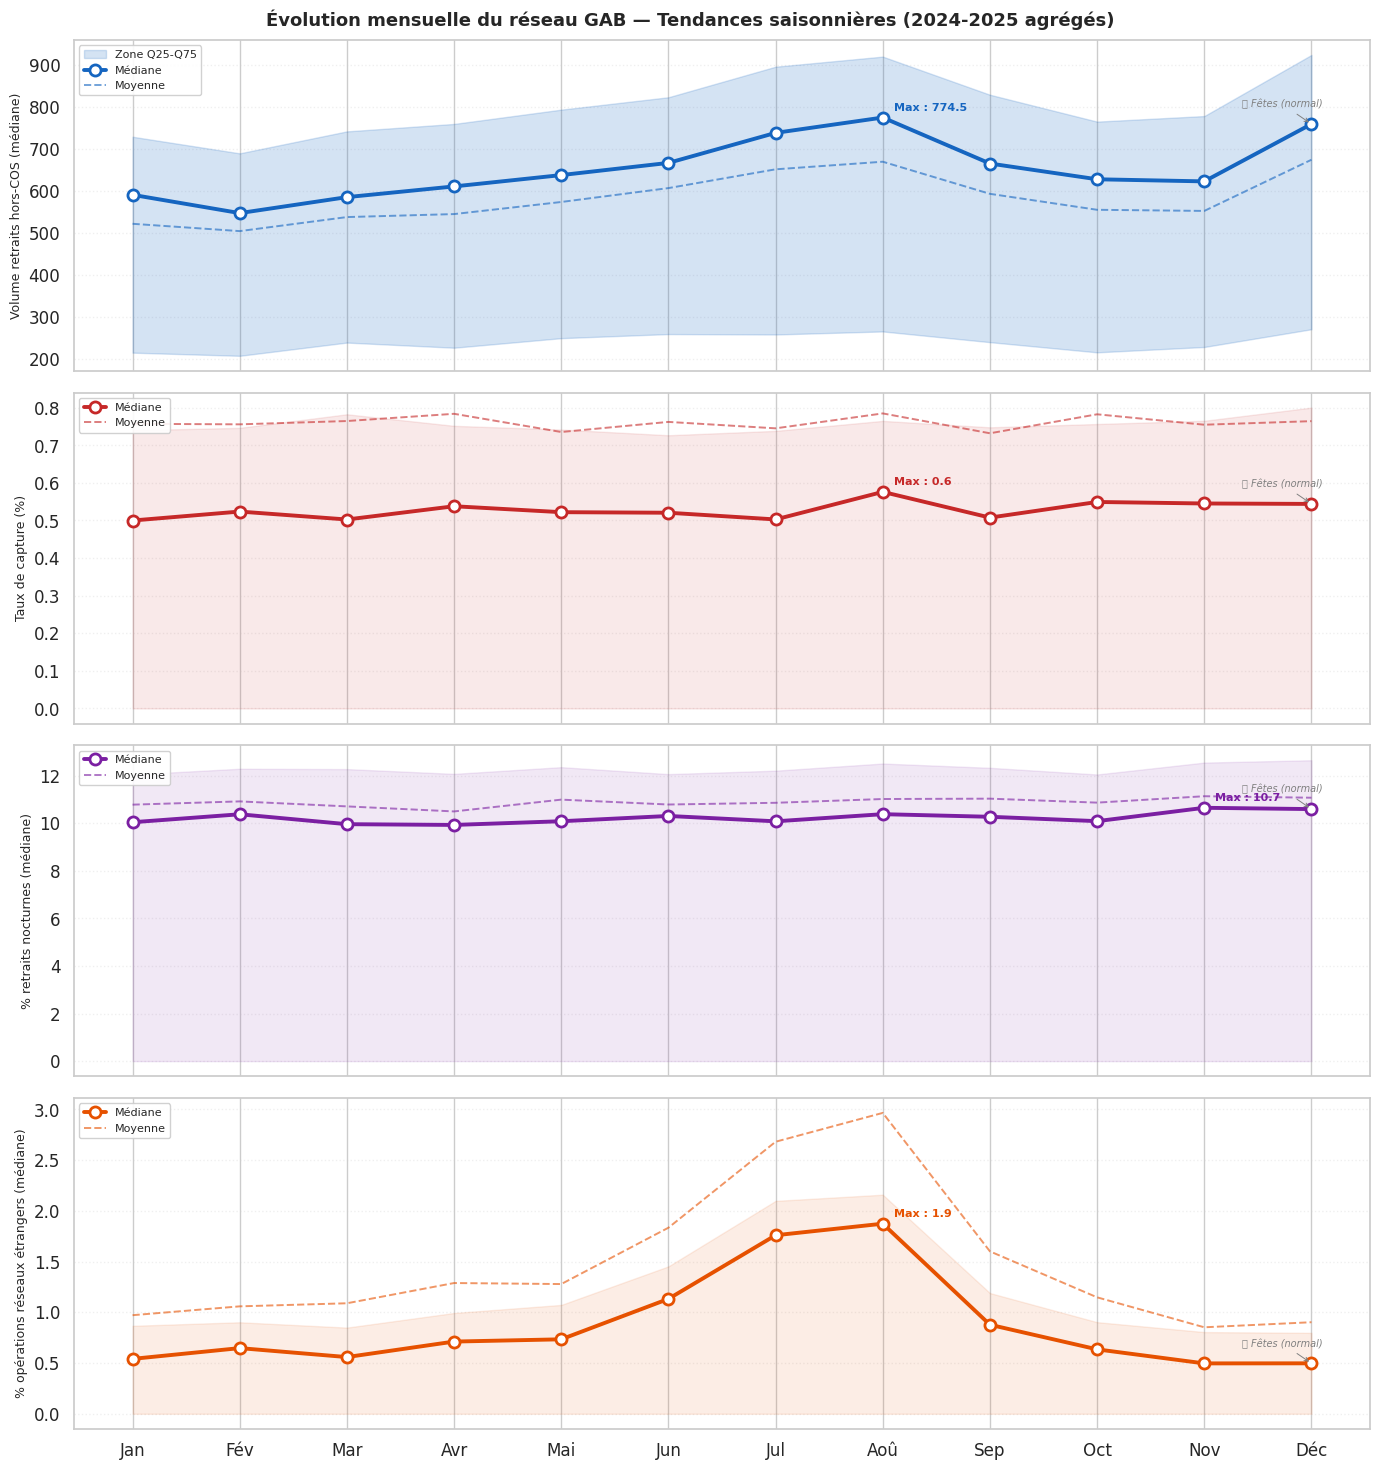


📅 % de GAB atypiques par mois (toutes années) :
    Jan : █████                10.0%
    Fév : █████                10.0%
    Mar : █████                10.0%
    Avr : █████                10.0%
    Mai : █████                10.0%
    Jun : █████                10.0%
    Jul : █████                10.0%
    Aoû : █████                10.0%
    Sep : █████                10.0%
    Oct : █████                10.0%
    Nov : █████                10.0%
    Déc : █████                10.0%

💡 La médiane lisse les outliers — les courbes sont stables et interprétables.
   Décembre : pic normal (fêtes). Été : hausse normale (tourisme).


In [12]:
# ── 6.1 Évolution mensuelle — vue saisonnière (2024-2025-2026 agrégés) ─────
# On agrège par mois toutes années confondues pour dégager la tendance saisonnière.
# La médiane est plus robuste que la moyenne face aux outliers.

MOIS_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

df_temps = df.groupby('mois').agg(
    ret_nb_med    = ('ret_nb_horscos',       'median'),
    ret_nb_moy    = ('ret_nb_horscos',       'mean'),
    ret_nb_p75    = ('ret_nb_horscos',       lambda x: x.quantile(.75)),
    ret_nb_p25    = ('ret_nb_horscos',       lambda x: x.quantile(.25)),
    taux_cap_med  = ('taux_capture_pct',     'median'),
    taux_cap_moy  = ('taux_capture_pct',     'mean'),
    taux_cap_p75  = ('taux_capture_pct',     lambda x: x.quantile(.75)),
    pct_nuit_med  = ('ret_pct_nuit',         'median'),
    pct_nuit_moy  = ('ret_pct_nuit',         'mean'),
    pct_nuit_p75  = ('ret_pct_nuit',         lambda x: x.quantile(.75)),
    pct_etr_med   = ('pct_reseaux_etrangers','median'),
    pct_etr_moy   = ('pct_reseaux_etrangers','mean'),
    pct_etr_p75   = ('pct_reseaux_etrangers',lambda x: x.quantile(.75)),
    nb_atypiques  = ('flag_atypique',        'sum'),
    n_obs         = ('num_automate',         'count'),
).reset_index()

df_temps['pct_atypiques'] = (df_temps['nb_atypiques'] / df_temps['n_obs'] * 100).round(1)
annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))

fig, axes = plt.subplots(4, 1, figsize=(14, 15), sharex=True)
fig.suptitle(f'Évolution mensuelle du réseau GAB — Tendances saisonnières ({annees_str} agrégés)',
             fontsize=13, fontweight='bold')

series = [
    (axes[0], 'ret_nb_med',  'ret_nb_moy',  'ret_nb_p25',  'ret_nb_p75',
     COULEUR_NORMAL,   '#E3F2FD', 'Volume retraits hors-COS (médiane)'),
    (axes[1], 'taux_cap_med','taux_cap_moy', None,          'taux_cap_p75',
     COULEUR_ANOMALIE, '#FFEBEE', 'Taux de capture (%)'),
    (axes[2], 'pct_nuit_med','pct_nuit_moy', None,          'pct_nuit_p75',
     '#7B1FA2',        '#F3E5F5', '% retraits nocturnes (médiane)'),
    (axes[3], 'pct_etr_med', 'pct_etr_moy',  None,          'pct_etr_p75',
     '#E65100',        '#FFF3E0', '% opérations réseaux étrangers (médiane)'),
]

for ax, col_med, col_moy, col_p25, col_p75, color, _, label in series:
    x = df_temps['mois']
    if col_p25 and col_p25 in df_temps.columns:
        ax.fill_between(x, df_temps[col_p25], df_temps[col_p75],
                        alpha=0.18, color=color, label='Zone Q25-Q75')
    elif col_p75 in df_temps.columns:
        ax.fill_between(x, 0, df_temps[col_p75], alpha=0.10, color=color)

    ax.plot(x, df_temps[col_med], 'o-', color=color, lw=2.8, ms=8,
            markerfacecolor='white', markeredgewidth=2, label='Médiane', zorder=3)
    ax.plot(x, df_temps[col_moy], '--', color=color, lw=1.4, alpha=0.6,
            label='Moyenne', zorder=2)

    idx_max = df_temps[col_med].idxmax()
    ax.annotate(f'Max : {df_temps[col_med].max():.1f}',
                xy=(x[idx_max], df_temps[col_med][idx_max]),
                xytext=(8,5), textcoords='offset points',
                fontsize=8, color=color, fontweight='bold')

    if 12 in x.values:
        dec_val = df_temps.loc[df_temps['mois']==12, col_med].values[0]
        ax.annotate('🎄 Fêtes (normal)', xy=(12, dec_val),
                    xytext=(-50,12), textcoords='offset points',
                    fontsize=7, color='grey', style='italic',
                    arrowprops={'arrowstyle':'->','color':'grey','lw':0.7})

    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_LABELS)

plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📅 % de GAB atypiques par mois (toutes années) :')
for _, row in df_temps.iterrows():
    barre = '█' * max(1, int(row['pct_atypiques']/2))
    flag  = '  ⚠️' if row['pct_atypiques'] > 10 else ''
    print(f'   {MOIS_LABELS[int(row["mois"])-1]:>4} : {barre:<20} {row["pct_atypiques"]:.1f}%{flag}')
print('\n💡 La médiane lisse les outliers — les courbes sont stables et interprétables.')
print('   Décembre : pic normal (fêtes). Été : hausse normale (tourisme).')


## 7. 🗺️ Analyse Géographique

La localisation d'un GAB influence fortement son comportement.  
Un GAB en centre-ville traite naturellement plus de retraits qu'un GAB rural.  
La carte nous permet de **contextualiser** chaque anomalie géographiquement.

In [13]:
# ── 7.1 Carte interactive — contexte géographique réaliste ─────────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

agg_geo = {
    'longitude':         ('longitude',              'first'),
    'latitude':          ('latitude',               'first'),
    'ret_nb_moyen':      ('ret_nb_horscos',         'mean'),
    'taux_cap_moyen':    ('taux_capture_pct',       'mean'),
    'type_gab':          ('type_gab_e_i',           'first'),
    'cp':                (cp_col,                   'first'),
    'contexte_geo':      ('contexte_geo',           'first'),
    'pct_etranger':      ('pct_reseaux_etrangers',  'mean'),
    'flag_max':          ('flag_atypique',          'max'),
    'nb_mois_atypiques': ('flag_atypique',          'sum'),
}
if 'raison_atypisme' in df.columns:
    agg_geo['raison'] = ('raison_atypisme', 'first')

df_geo = df.groupby('num_automate').agg(**agg_geo).reset_index()
df_geo['statut'] = df_geo['flag_max'].map({0:'Normal', 1:'Atypique'})

hover_data = {
    'cp':               True,
    'contexte_geo':     True,
    'type_gab':         True,
    'ret_nb_moyen':     ':.0f',
    'taux_cap_moyen':   ':.2f',
    'nb_mois_atypiques':True,
    'pct_etranger':     ':.1f',
    'statut':           False,
    'latitude':         False,
    'longitude':        False,
}
if 'raison' in df_geo.columns:
    hover_data['raison'] = True

fig_map = px.scatter_mapbox(
    df_geo,
    lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'Normal': COULEUR_NORMAL, 'Atypique': COULEUR_ANOMALIE},
    size='ret_nb_moyen',
    size_max=22,
    hover_name='num_automate',
    hover_data=hover_data,
    mapbox_style='carto-positron',
    zoom=4.5, center={'lat': 46.6, 'lon': 2.2},   # centre France métropolitaine
    title='🗺️ Carte du réseau GAB — Anomalies et contexte géographique',
    height=600,
)
fig_map.update_layout(
    margin={'r':0,'t':45,'l':0,'b':0},
    legend_title_text='Statut',
)
fig_map.show()

print()
print('📊 Répartition par contexte géographique :')
print(df_geo.groupby(['contexte_geo','statut']).size().unstack(fill_value=0).to_string())

💡 Symboles différents = contextes différents (Métropole vs DOM-TOM).
   GAB en Guyane/Guadeloupe/Réunion → volume faible = NORMAL par définition.

📊 Répartition par contexte géographique :
statut        Atypique  Normal
contexte_geo                  
Guadeloupe           1       5
Guyane               1      11
Métropole            7      74
Réunion              3      13
Saint-Martin         0       5


## 8. 🤖 Modélisation — Détection d'Anomalies

### Pourquoi l'Isolation Forest ?

| Modèle | Principe | Adapté ici ? |
|---|---|---|
| **Isolation Forest** | Isole les points rares par partitions aléatoires | ✅ Oui — rapide, robuste, interprétable |
| Local Outlier Factor | Densité locale vs voisins | ⚠️ Lent sur grands datasets |
| One-Class SVM | Frontière autour des normaux | ⚠️ Difficile à paramétrer |
| Seuils statistiques | z-score, IQR | ⚠️ Univarié, ne capte pas les interactions |

**Isolation Forest** est notre choix car :
- Il gère bien les **données multivariées** (50+ colonnes)
- Il est **rapide** sur de grands volumes
- Il produit un **score d'anomalie** continu (pas seulement un label)
- Il est **intuitif** : un point difficile à isoler = normal, facile à isoler = anormal

In [14]:
# ── 8.1 Sélection des features pour le modèle — alignée SQL v3 + CUP ─────────
FEATURES_MODELE = [
    # Volume et montants (hors COS)
    'ret_nb_horscos',
    'ret_montant_moyen',
    'ret_montant_max',
    'ret_montant_stddev',
    'ret_montant_total',
    # Capture hors COS
    'taux_capture_pct',
    'ratio_capture',
    # Temporel
    'ret_pct_nuit',
    'ret_pct_weekend',
    'score_horaires_atypiques',
    # Features enrichies
    'intensite_retrait_ajustee',
    'concentration_reseau',
    'cv_montant',
    # Réseaux étrangers (dont CUP)
    'pct_reseaux_etrangers',
    'nb_ope_reseaux_etrangers',
    'nb_ope_reseau_jcb',
    'nb_ope_reseau_amex',
    'nb_ope_reseau_carte_diners_et_discovery',
    'nb_ope_reseau_cup',           # ← NOUVEAU CUP
    # Réseaux principaux
    'nb_ope_reseau_cb',
    'nb_ope_reseau_visa',
    'nb_ope_reseau_mastercard',
    'nb_ope_reseau_interne',
]

# Filtrer selon disponibilité réelle dans le dataset
FEATURES_MODELE = [f for f in FEATURES_MODELE if f in df.columns]

X = df[FEATURES_MODELE].fillna(0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Matrice features : {X_scaled.shape[0]:,} lignes × {X_scaled.shape[1]} features')
print('\nFeatures utilisées :')
for i, f in enumerate(FEATURES_MODELE, 1):
    marker = ' ← CUP' if 'cup' in f else ''
    print(f'   {i:2d}. {f}{marker}')


✅ Matrice features : 2,880 lignes × 23 features

Features utilisées :
    1. ret_nb_horscos
    2. ret_montant_moyen
    3. ret_montant_max
    4. ret_montant_stddev
    5. ret_montant_total
    6. taux_capture_pct
    7. ratio_capture
    8. ret_pct_nuit
    9. ret_pct_weekend
   10. score_horaires_atypiques
   11. intensite_retrait_ajustee
   12. concentration_reseau
   13. cv_montant
   14. pct_reseaux_etrangers
   15. nb_ope_reseaux_etrangers
   16. nb_ope_reseau_jcb
   17. nb_ope_reseau_amex
   18. nb_ope_reseau_carte_diners_et_discovery
   19. nb_ope_reseau_cup ← CUP
   20. nb_ope_reseau_cb
   21. nb_ope_reseau_visa
   22. nb_ope_reseau_mastercard
   23. nb_ope_reseau_interne


In [15]:
# ── 8.3 Entraînement Isolation Forest ─────────────────────────────────────────
# contamination = proportion estimée d'anomalies dans le réseau (~5%)
modele = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df['score_anomalie'] = modele.fit_predict(X_scaled)  # -1 = anomalie, +1 = normal
df['score_if']       = modele.score_samples(X_scaled)  # plus bas = plus anormal

# Normalisation du score en [0, 1] pour lisibilité métier
score_min, score_max = df['score_if'].min(), df['score_if'].max()
df['score_risque'] = 1 - (df['score_if'] - score_min) / (score_max - score_min)
# score_risque proche de 1 = très anormal

df['est_anomalie'] = (df['score_anomalie'] == -1).astype(int)

n_anomalies = df['est_anomalie'].sum()
print(f'🚨 GAB atypiques détectés : {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)')

🚨 GAB atypiques détectés : 144 / 2880 (5.0%)


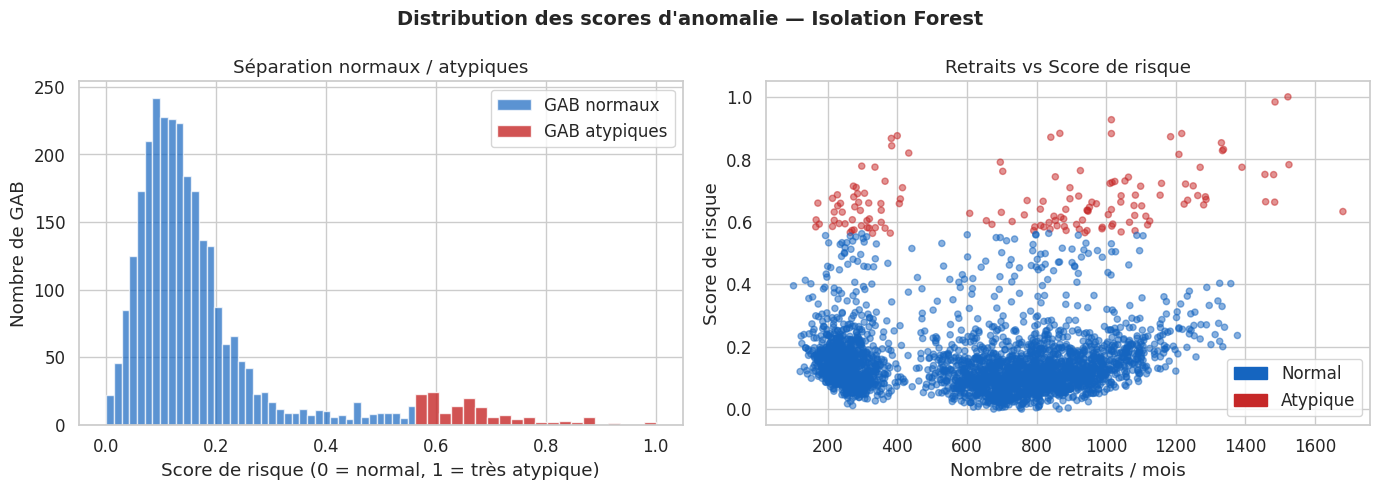

In [16]:
# ── 8.4 Visualisation du score d'anomalie ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des scores d\'anomalie — Isolation Forest', fontsize=14, fontweight='bold')

# Histogramme des scores
ax = axes[0]
ax.hist(df[df['est_anomalie']==0]['score_risque'], bins=40,
        color=COULEUR_NORMAL, alpha=0.7, label='GAB normaux')
ax.hist(df[df['est_anomalie']==1]['score_risque'], bins=20,
        color=COULEUR_ANOMALIE, alpha=0.8, label='GAB atypiques')
ax.set_xlabel('Score de risque (0 = normal, 1 = très atypique)')
ax.set_ylabel('Nombre de GAB')
ax.set_title('Séparation normaux / atypiques')
ax.legend()

# Scatter retraits vs score risque
ax2 = axes[1]
couleurs = [COULEUR_ANOMALIE if a==1 else COULEUR_NORMAL for a in df['est_anomalie']]
ax2.scatter(df['ret_nb'], df['score_risque'], c=couleurs, alpha=0.5, s=20)
ax2.set_xlabel('Nombre de retraits / mois')
ax2.set_ylabel('Score de risque')
ax2.set_title('Retraits vs Score de risque')
patch_n = mpatches.Patch(color=COULEUR_NORMAL,   label='Normal')
patch_a = mpatches.Patch(color=COULEUR_ANOMALIE, label='Atypique')
ax2.legend(handles=[patch_n, patch_a])

plt.tight_layout()
plt.savefig('scores_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

## 8bis. 🔬 K-Means — 8 familles comportementales

### Principe : le K-Means découvre les familles sans les connaître à l'avance

On fournit les données au modèle, il regroupe les GAB qui **se ressemblent**
dans leur comportement. On donne ensuite un **nom métier** à chaque groupe.

**Les 8 familles attendues :**

| # | Famille | Signal dominant | Interprétation |
|---|---|---|---|
| 1 | 🏙️ **Urbains forte activité** | Volume > 900/mois + montant élevé | Grande ville très fréquentée |
| 2 | 🌆 **Urbains standard** | Volume moyen + comportement stable | Zone urbaine classique |
| 3 | 🗺️ **Touristiques** | % étranger modéré + pics été/fêtes | Ville touristique (Nice, Marseille…) |
| 4 | 🌍 **Dominante étrangère** | % réseaux étrangers élevé toute l'année | JCB/Amex très présents — stable ou suspect |
| 5 | 🌙 **Nocturnes** | % nuit > 25% toute l'année | Activité hors horaires — à surveiller |
| 6 | 🏔️ **Isolés / montagne** | Volume très faible + forte saisonnalité | Zone rurale peu fréquentée |
| 7 | 📈 **Activité instable** | CV élevé (forte variabilité mois à mois) | Comportement irrégulier — à investiguer |
| 8 | 🟢 **Standard** | Tous indicateurs dans la norme | Comportement de référence |

### Ce qu'on fait ensuite

1. **Visualisation PCA** : voir si les familles sont bien séparées
2. **Carte géographique** : vérifier si les familles se concentrent là où on les attend
3. **Suivi temporel** : si un GAB **change de famille** d'un mois à l'autre → étiquette ⚠️ "comportement atypique à surveiller"

---


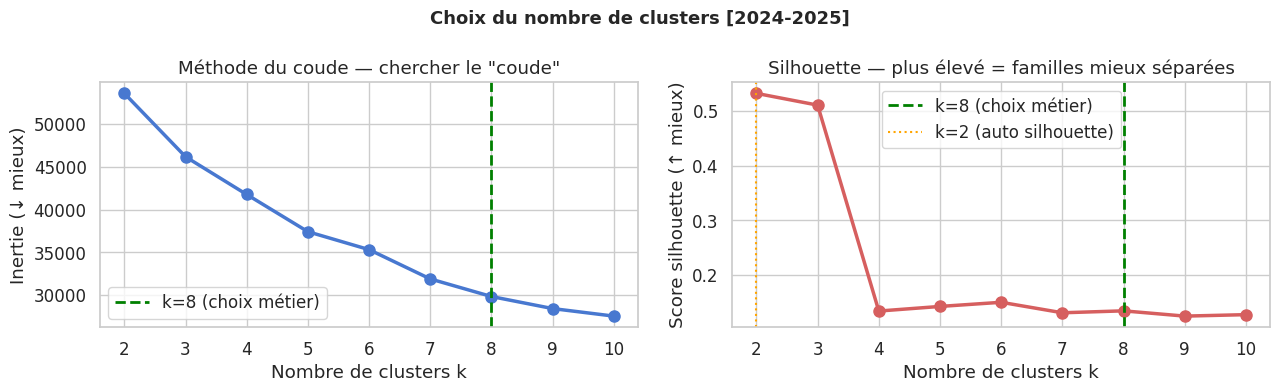

✅ k=8 retenu | silhouette k=8 = 0.134
   k auto (silhouette max) = 2 (0.532)
   On privilégie k=8 pour correspondre aux 8 familles métier.


In [17]:
# ── 8bis.1 Choix du k — Méthode du coude + Silhouette ────────────────────────
# On cherche le k optimal, mais on vise k=8 pour couvrir les 8 familles métier.
annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))

SAMPLE_SIZE = min(5000, len(df))
np.random.seed(42)
idx_s = np.random.choice(len(df), SAMPLE_SIZE, replace=False)
X_s   = X_scaled[idx_s]

inertias, sil = [], []
K_range = range(2, 11)
for k in K_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labs = km.fit_predict(X_s)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(X_s, labs, sample_size=min(2000, SAMPLE_SIZE)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Choix du nombre de clusters [{annees_str}]', fontsize=13, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', lw=2.5, ms=8)
axes[0].axvline(8, color='green', ls='--', lw=2, label='k=8 (choix métier)')
axes[0].set(xlabel='Nombre de clusters k', ylabel='Inertie (↓ mieux)',
            title='Méthode du coude — chercher le "coude"')
axes[0].set_xticks(list(K_range))
axes[0].legend()

k_auto = list(K_range)[sil.index(max(sil))]
axes[1].plot(list(K_range), sil, 'ro-', lw=2.5, ms=8)
axes[1].axvline(8,      color='green',  ls='--', lw=2,   label='k=8 (choix métier)')
axes[1].axvline(k_auto, color='orange', ls=':', lw=1.5,  label=f'k={k_auto} (auto silhouette)')
axes[1].set(xlabel='Nombre de clusters k', ylabel='Score silhouette (↑ mieux)',
            title='Silhouette — plus élevé = familles mieux séparées')
axes[1].set_xticks(list(K_range))
axes[1].legend()

plt.tight_layout()
plt.savefig('clustering_k.png', dpi=150, bbox_inches='tight')
plt.show()

K_FINAL = 8
sil_k8 = sil[list(K_range).index(8)]
print(f'✅ k=8 retenu | silhouette k=8 = {sil_k8:.3f}')
print(f'   k auto (silhouette max) = {k_auto} ({max(sil):.3f})')
print(f'   On privilégie k=8 pour correspondre aux 8 familles métier.')


In [20]:
from sklearn.preprocessing import RobustScaler

annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))

# ── Features comportementales — colonnes SQL v3 uniquement ───────────────────
FEAT_CLUST = [
    'ret_pct_nuit',               # 🌙 Nocturnes
    'ret_pct_weekend',            # 🗺️ Touristiques
    'pct_reseaux_etrangers',      # 🌍 Dominante étrangère + 🗺️ Touristiques
    'nb_ope_reseau_jcb',          # 🌍 JCB
    'nb_ope_reseau_amex',         # 🌍 Amex
    'nb_ope_reseau_cup',          # CUP (nom exact SQL v3)
    'intensite_retrait_ajustee',  # 🏙️ Urbain fort ↔ 🏔️ Isolé faible
    'ret_montant_moyen_eur',      # 🏙️ Montant élevé = urbain dense
    'taux_capture_pct',           # Signal anomalie
    'cv_montant',                 # 📈 Variabilité mensuelle
    'score_horaires_atypiques',   # Nuit + weekend combinés
    'concentration_reseau',       # Un seul réseau domine ?
]
FEAT_CLUST = [f for f in FEAT_CLUST if f in df.columns]
print(f'✅ Features clustering ({len(FEAT_CLUST)}) : {FEAT_CLUST}')

scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df[FEAT_CLUST].fillna(0))

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df['cluster'] = km_final.fit_predict(X_clust)

# ── Profil moyen par cluster ──────────────────────────────────────────────────
feat_profil = [
    'ret_nb_horscos', 'ret_montant_moyen_eur',
    'ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct',
    'pct_reseaux_etrangers', 'nb_ope_reseau_jcb', 'nb_ope_reseau_amex',
    'nb_ope_reseau_cup', 'intensite_retrait_ajustee', 'cv_montant', 'est_anomalie',
]
feat_profil = [f for f in feat_profil if f in df.columns]
profil = df.groupby('cluster')[feat_profil].mean().round(2)

# ── Seuils adaptatifs sur les données réelles ─────────────────────────────────
Q = {
    'nuit_75':    df['ret_pct_nuit'].quantile(.75),
    'nuit_50':    df['ret_pct_nuit'].median(),
    'etr_75':     df['pct_reseaux_etrangers'].quantile(.75),
    'etr_50':     df['pct_reseaux_etrangers'].median(),
    'jcb_75':     df['nb_ope_reseau_jcb'].quantile(.75),
    'intens_75':  df['intensite_retrait_ajustee'].quantile(.75),
    'intens_50':  df['intensite_retrait_ajustee'].median(),
    'intens_25':  df['intensite_retrait_ajustee'].quantile(.25),
    'moy_75':     df['ret_montant_moyen_eur'].quantile(.75),
    'cv_75':      df['cv_montant'].quantile(.75),
    'weekend_65': df['ret_pct_weekend'].quantile(.65),
}

# ════════════════════════════════════════════════════════════════════════════
# NOMMAGE UNIQUE — algorithme d'affectation par score matriciel
#
# Pour chaque paire (cluster, famille) → score de correspondance.
# On trie par score décroissant et on affecte de façon exclusive :
# une famille ne peut être attribuée qu'à UN SEUL cluster.
# Résultat garanti : 8 noms tous différents dans la carte et la légende PCA.
# ════════════════════════════════════════════════════════════════════════════

FAMILLES_CIBLES = [
    '🌙 Nocturnes',
    '🌍 Dominante étrangère',
    '🏔️ Isolés / montagne',
    '📈 Activité instable',
    '🗺️ Touristiques',
    '🏙️ Urbains forte activité',
    '🌆 Urbains standard',
    '🟢 Standard',
]

def score_famille(row, famille):
    """Score de correspondance cluster↔famille. Plus élevé = meilleur match."""
    nuit    = row.get('ret_pct_nuit',             0)
    etr     = row.get('pct_reseaux_etrangers',    0)
    jcb     = row.get('nb_ope_reseau_jcb',        0)
    amx     = row.get('nb_ope_reseau_amex',       0)
    intens  = row.get('intensite_retrait_ajustee', 0)
    moy     = row.get('ret_montant_moyen_eur',    0)
    cv      = row.get('cv_montant',               0)
    weekend = row.get('ret_pct_weekend',          0)

    if famille == '🌙 Nocturnes':
        return nuit / (Q['nuit_75'] + 1e-9)

    elif famille == '🌍 Dominante étrangère':
        jcb_s = jcb / (Q['jcb_75'] + 1e-9)
        etr_s = etr / (Q['etr_75'] + 1e-9)
        return jcb_s * 0.5 + etr_s * 0.5

    elif famille == '🏔️ Isolés / montagne':
        if intens <= 0: return 10.0
        return Q['intens_25'] / (intens + 1e-9)

    elif famille == '📈 Activité instable':
        return cv / (Q['cv_75'] + 1e-9)

    elif famille == '🗺️ Touristiques':
        etr_s     = etr     / (Q['etr_50']     + 1e-9)
        weekend_s = weekend / (Q['weekend_65'] + 1e-9)
        return etr_s * 0.4 + weekend_s * 0.6

    elif famille == '🏙️ Urbains forte activité':
        intens_s = intens / (Q['intens_75'] + 1e-9)
        moy_s    = moy    / (Q['moy_75']    + 1e-9)
        return intens_s * 0.6 + moy_s * 0.4

    elif famille == '🌆 Urbains standard':
        if Q['intens_75'] > 0:
            ratio = intens / Q['intens_75']
            return ratio * (1 - abs(ratio - 0.65))
        return intens / (Q['intens_50'] + 1e-9)

    else:  # 🟢 Standard : meilleur score si aucun signal fort
        top = max(
            nuit    / (Q['nuit_75']   + 1e-9),
            etr     / (Q['etr_75']    + 1e-9),
            cv      / (Q['cv_75']     + 1e-9),
        )
        return 1.0 / (top + 0.1)

# Matrice de scores K×8
import numpy as _np
scores = _np.zeros((K_FINAL, len(FAMILLES_CIBLES)))
for cid in range(K_FINAL):
    row = profil.loc[cid]   # ← ton fix : .loc au lieu de .iloc
    for j, fam in enumerate(FAMILLES_CIBLES):
        scores[cid, j] = score_famille(row, fam)

# Affectation greedy : trier toutes les paires (score, cluster, famille)
# par score décroissant, affecter sans répétition
pairs = sorted(
    [(scores[c,j], c, fam) for c in range(K_FINAL) for j,fam in enumerate(FAMILLES_CIBLES)],
    key=lambda x: -x[0]
)
NOMS_CLUSTERS = {}
familles_prises = set()
for score_val, cid, fam in pairs:
    if cid not in NOMS_CLUSTERS and fam not in familles_prises:
        NOMS_CLUSTERS[cid] = fam
        familles_prises.add(fam)
    if len(NOMS_CLUSTERS) == K_FINAL:
        break

# Sécurité : si un cluster n'a pas de nom (ne devrait pas arriver)
for cid in range(K_FINAL):
    if cid not in NOMS_CLUSTERS:
        NOMS_CLUSTERS[cid] = '🟢 Standard'

df['cluster_nom'] = df['cluster'].map(NOMS_CLUSTERS)

# Vérification unicité
noms_liste = list(NOMS_CLUSTERS.values())
doublons = [n for n in set(noms_liste) if noms_liste.count(n) > 1]
assert not doublons, f'⚠️ Doublons détectés : {doublons}'
print(f'✅ Nommage unique vérifié — {len(set(noms_liste))} noms distincts.')
print('   Familles attribuées :')
for cid in range(K_FINAL):
    print(f'   Cluster {cid} → {NOMS_CLUSTERS[cid]}')

# Couleurs (mapping par emoji — 2 premiers caractères)
COULEURS_NOMS = {}
for cid, nom in NOMS_CLUSTERS.items():
    found = False
    for fam_key, fam_col in COULEURS_FAMILLES.items():
        if nom[:2] == fam_key[:2]:
            COULEURS_NOMS[nom] = fam_col; found = True; break
    if not found:
        COULEURS_NOMS[nom] = PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)]

# ── Affichage profil et répartition ──────────────────────────────────────────
print(f'\n📊 Profil moyen par famille [{annees_str}] :')
display(profil.rename(index=NOMS_CLUSTERS).style
    .background_gradient(cmap='YlOrRd',
                         subset=[f for f in feat_profil if f != 'est_anomalie'])
    .format('{:.2f}'))

print('\n📋 Répartition des 8 familles :')
dist = df.groupby(['cluster','cluster_nom']).agg(
    GAB_uniques  = ('num_automate', 'nunique'),
    Observations = ('num_automate', 'count'),
    pct_atyp     = ('est_anomalie', 'mean'),
).reset_index()
dist['% Atypiques'] = (dist['pct_atyp']*100).round(1)
print(f'   {"Famille":<35} {"GAB":>6}  {"Obs.":>8}  {"% Atyp.":>8}')
print('   ' + '─'*65)
for _,r in dist.sort_values('cluster').iterrows():
    print(f'   {r["cluster_nom"]:<35} {r["GAB_uniques"]:>6.0f}  '
          f'{r["Observations"]:>8.0f}  {r["% Atypiques"]:>7.1f}%')

# ── Détection changement de famille (ton fix : .map()) ───────────────────────
print('\n' + '═'*65)
print('  🔄 SUIVI TEMPOREL — Un GAB qui change de famille = comportement atypique')
print('═'*65)

df_s = df.sort_values(['num_automate','annee','mois']).copy()
df_s['famille_prec'] = df_s.groupby('num_automate')['cluster_nom'].shift(1)
df_s['changement_famille'] = (
    (df_s['cluster_nom'] != df_s['famille_prec']) &
    df_s['famille_prec'].notna()
).astype(int)

nb_chg = df_s.groupby('num_automate')['changement_famille'].sum()
df['nb_changements'] = df['num_automate'].map(nb_chg)   # ← ton fix : .map()

df = df.merge(
    df_s[['num_automate','annee','mois','famille_prec','changement_famille']],
    on=['num_automate','annee','mois'], how='left'
)

def etiquette_comportement(n):
    if n == 0:   return '✅ Stable'
    if n <= 2:   return '🟡 Légèrement instable'
    if n <= 5:   return '🟠 Instable'
    return              '🔴 ⚠️ Comportement atypique à surveiller'

df['etiquette_kmeans'] = df['nb_changements'].apply(etiquette_comportement)

print(f'\n📊 Distribution des étiquettes [{annees_str}] :')
dist_eti = df.groupby('etiquette_kmeans')['num_automate'].nunique().sort_values(ascending=False)
for k,v in dist_eti.items():
    barre = '█' * max(1, int(v/dist_eti.max()*30))
    print(f'   {k:<45}: {barre:<32} {v} GAB')

print(f'\n🔄 Top 10 GAB les plus instables :')
top_inst = (df.groupby('num_automate')['nb_changements'].first()
             .sort_values(ascending=False).head(10))
for gab,n in top_inst.items():
    print(f'   {gab} : {n:.0f} changements → {etiquette_comportement(n)}')


✅ Features clustering (12) :
   · ret_pct_nuit
   · ret_pct_weekend
   · pct_reseaux_etrangers
   · nb_ope_reseau_jcb
   · nb_ope_reseau_amex
   · nb_ope_reseau_cup
   · intensite_retrait_ajustee
   · ret_montant_moyen_eur
   · taux_capture_pct
   · cv_montant
   · score_horaires_atypiques
   · concentration_reseau

📊 Profil moyen par famille [2024-2025] :


,ret_nb_horscos,ret_montant_moyen_eur,ret_pct_nuit,ret_pct_weekend,taux_capture_pct,pct_reseaux_etrangers,nb_ope_reseau_jcb,nb_ope_reseau_amex,nb_ope_reseau_cup,intensite_retrait_ajustee,cv_montant,est_anomalie
cluster,,,,,,,,,,,,
🌙 Nocturnes,543.00,159.27,41.98,28.81,1.00,1.06,5.15,3.65,0.67,23.64,1.14,0.36
🌍 Dominante étrangère,832.75,164.22,12.22,24.13,0.94,39.79,502.08,178.42,0.75,33.10,1.07,1.00
🌍 Dominante étrangère (Cluster 2),712.92,182.82,10.71,22.17,0.92,21.73,158.85,79.65,0.69,26.60,0.98,0.92
🌍 Dominante étrangère (Cluster 3),682.28,165.35,12.70,24.13,9.67,2.47,12.82,8.86,0.68,26.26,1.08,0.82
🟢 Standard,504.04,475.78,11.41,23.24,0.71,1.14,5.13,4.49,0.55,19.88,0.38,0.00
🌍 Dominante étrangère (Cluster 5),847.00,152.82,11.48,23.22,0.83,29.93,273.90,103.40,0.20,33.37,1.17,1.00
🌆 Urbains standard,577.87,150.09,9.96,22.01,0.51,0.87,4.23,2.78,0.67,22.47,0.40,0.00
🌍 Dominante étrangère (Cluster 7),677.79,172.49,10.15,20.55,0.84,13.01,76.62,54.29,0.62,28.79,1.07,0.58



📋 Répartition des 8 familles :
   Famille                              GAB uniques      Obs.   % Atyp.
   ──────────────────────────────────────────────────────────────────────
   🌙 Nocturnes                                    3        72     36.1%
   🌍 Dominante étrangère                          3        12    100.0%
   🌍 Dominante étrangère                          3        26     92.3%
   🌍 Dominante étrangère                          3        71     81.7%
   🟢 Standard                                     3        69      0.0%
   🌍 Dominante étrangère                          3        10    100.0%
   🌆 Urbains standard                           111      2596      0.0%
   🌍 Dominante étrangère                          3        24     58.3%

═════════════════════════════════════════════════════════════════
  🔄 ÉTIQUETAGE COMPORTEMENTAL — Suivi temporel K-Means
  On observe chaque GAB mois par mois : reste-t-il dans la même famille ?
══════════════════════════════════════════════════

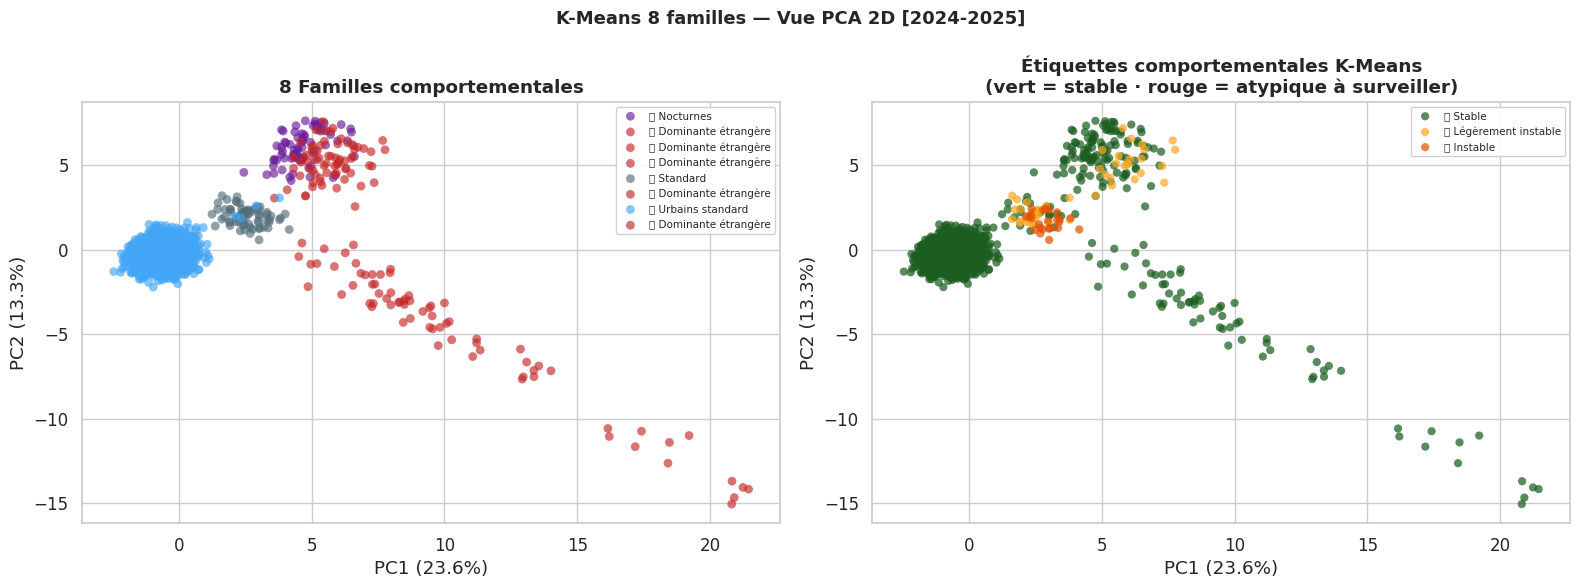

💡 36.9% de variance expliquée.



📊 Distribution famille × type de zone [2024-2025] :
contexte_geo           Guadeloupe  Guyane  Métropole  Réunion  Saint-Martin
famille_dom                                                                
🌆 Urbains standard              5      11         74       13             5
🌍 Dominante étrangère           0       0          4        2             0
🌙 Nocturnes                     0       1          1        1             0
🟢 Standard                      1       0          2        0             0

💡 Vérification géographique attendue :
   🏔️ Isolés / montagne   → zone insulaire (97xxx = DOM-TOM)
   🗺️ Touristiques        → Nice (06), Marseille (13), Bordeaux (33)
   🏙️ Urbains forte activ.→ Paris (75), Lyon (69)
   🌙 Nocturnes           → dispersés — aucune zone prédéfinie
   🌍 Dom. étrangère      → dispersés — à investiguer


HTML(value='<hr><b style="font-size:13px">🔍 Rechercher un GAB sur la carte des familles</b>')

Output()

In [21]:
# ── 8bis.3 PCA 2D + Carte géographique des 8 familles ────────────────────────
annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

# ── 1. PCA 2D — les familles sont-elles bien séparées ? ──────────────────────
pca_clust = PCA(n_components=2, random_state=42)
Xp = pca_clust.fit_transform(X_scaled)
df['_pca1'], df['_pca2'] = Xp[:,0], Xp[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means 8 familles — Vue PCA 2D [{annees_str}]',
             fontsize=13, fontweight='bold')

# Graphique 1 : 8 familles colorées
ax = axes[0]
for cid in sorted(df['cluster'].unique()):
    nom  = NOMS_CLUSTERS[cid]
    col  = COULEURS_NOMS.get(nom, PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)])
    mask = df['cluster'] == cid
    ax.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
               c=col, label=nom, alpha=0.65, s=40, edgecolors='none')
ax.set_title('8 Familles comportementales', fontweight='bold')
ax.legend(loc='best', fontsize=7.5, framealpha=0.9)
ax.set_xlabel(f'PC1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

# Graphique 2 : étiquettes de stabilité
palette_eti = {
    '✅ Stable':                              '#1B5E20',
    '🟡 Légèrement instable':                '#F9A825',
    '🟠 Instable':                            '#E65100',
    '🔴 ⚠️ Comportement atypique à surveiller':'#B71C1C',
}
ax2 = axes[1]
for eti, col in palette_eti.items():
    mask = df['etiquette_kmeans'] == eti
    if mask.sum() == 0: continue
    ax2.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
                c=col, label=eti, s=35, alpha=0.72, edgecolors='none')
ax2.set_title('Étiquettes comportementales K-Means\n'
              '(vert = stable · rouge = atypique à surveiller)', fontweight='bold')
ax2.legend(loc='best', fontsize=7.5, framealpha=0.9)
ax2.set_xlabel(f'PC1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💡 {pca_clust.explained_variance_ratio_[:2].sum()*100:.1f}% de variance expliquée.')

# ══════════════════════════════════════════════════════════════════════════════
# 2. CARTE GÉOGRAPHIQUE DES 8 FAMILLES
# ──────────────────────────────────────────────────────────────────────────────
# Chaque point = 1 GAB coloré par sa FAMILLE DOMINANTE sur 2024-2025.
#
# Hypothèse géographique à vérifier :
#   🏙️ Urbains forte activité → Paris, Lyon (grands CPs)
#   🌆 Urbains standard       → villes moyennes
#   🗺️ Touristiques           → Nice (06), Marseille (13), Bordeaux (33)
#   🌍 Dominante étrangère    → dispersés (signal à investiguer)
#   🌙 Nocturnes              → dispersés (pas de corrélation géo attendue)
#   🏔️ Isolés / montagne      → zone rurale peu fréquentée
#   📈 Activité instable      → dispersés (à investiguer)
#   🟢 Standard               → partout
# ══════════════════════════════════════════════════════════════════════════════

# Colonnes réseau étranger exactes SQL v3
RESEAUX_ETR = {}
for col in ['nb_ope_reseau_jcb','nb_ope_reseau_amex',
            'nb_ope_reseau_cup','nb_ope_reseau_carte_diners_et_discovery']:
    if col in df.columns:
        nom = col.replace('nb_ope_reseau_','').replace('_et_discovery','').upper()
        RESEAUX_ETR[col] = nom

# Agrégation par GAB : famille dominante sur toute la période
agg_fam = {
    'latitude'      : ('latitude',            'first'),
    'longitude'     : ('longitude',           'first'),
    'cp'            : (cp_col,                'first'),
    'famille_dom'   : ('cluster_nom',          lambda x: x.value_counts().index[0]),
    'etiquette_dom' : ('etiquette_kmeans',     lambda x: x.value_counts().index[0]),
    'ret_nb_moy'    : ('ret_nb_horscos',       'mean'),
    'montant_moy'   : ('ret_montant_moyen_eur','mean'),
    'pct_nuit'      : ('ret_pct_nuit',         'mean'),
    'pct_weekend'   : ('ret_pct_weekend',      'mean'),
    'pct_etr'       : ('pct_reseaux_etrangers','mean'),
    'taux_cap'      : ('taux_capture_pct',     'mean'),
    'cv_moy'        : ('cv_montant',           'mean'),
    'nb_chgts'      : ('nb_changements',       'first'),
    'flag_atyp'     : ('flag_atypique',        'max'),
    'nb_mois_atyp'  : ('flag_atypique',        'sum'),
    'score_risque'  : ('score_risque',         'mean') if 'score_risque' in df.columns else ('flag_atypique','mean'),
}
for col, nom in RESEAUX_ETR.items():
    agg_fam[f'{nom.lower()}_moy'] = (col, 'mean')
if 'contexte_geo' in df.columns:
    agg_fam['contexte_geo'] = ('contexte_geo', 'first')

df_fam = df.groupby('num_automate').agg(**agg_fam).reset_index()
df_fam['sz'] = np.log1p(df_fam['ret_nb_moy'])*3 + 5
df_fam['statut_sql'] = df_fam['flag_atyp'].map({0:'✅ Normal', 1:'🔴 Atypique SQL'})

# Hover enrichi — toutes les infos utiles au survol
hover_fam = {
    'cp':True, 'ret_nb_moy':':.0f', 'montant_moy':':.0f',
    'pct_nuit':':.1f', 'pct_weekend':':.1f', 'pct_etr':':.1f',
    'taux_cap':':.2f', 'cv_moy':':.2f',
    'nb_chgts':True, 'etiquette_dom':True, 'nb_mois_atyp':True,
    'statut_sql':True, 'famille_dom':False,
    'latitude':False, 'longitude':False, 'sz':False,
}
if 'score_risque' in df_fam.columns: hover_fam['score_risque']=':.3f'
if 'contexte_geo' in df_fam.columns: hover_fam['contexte_geo']=True
for col, nom in RESEAUX_ETR.items():
    clef = f'{nom.lower()}_moy'
    if clef in df_fam.columns: hover_fam[clef] = ':.1f'

labels_fam = {
    'cp'           : 'Code postal',
    'ret_nb_moy'   : 'Retraits hors-COS (moy/mois)',
    'montant_moy'  : 'Montant moyen (€)',
    'pct_nuit'     : '% Nocturne (moy.)',
    'pct_weekend'  : '% Weekend (moy.)',
    'pct_etr'      : '% Réseaux étrangers (total)',
    'taux_cap'     : 'Taux de capture (%)',
    'cv_moy'       : 'Variabilité mensuelle (CV)',
    'nb_chgts'     : '🔄 Changements de famille',
    'etiquette_dom': '⚠️ Étiquette comportementale',
    'nb_mois_atyp' : 'Nb mois atypiques (SQL)',
    'statut_sql'   : 'Statut SQL',
    'score_risque' : 'Score risque IF',
    'contexte_geo' : 'Type de zone',
    'jcb_moy'      : 'JCB (nb op/mois moy.)',
    'amex_moy'     : 'Amex (nb op/mois moy.)',
    'cup_moy'       : 'CUP (nb op/mois moy.)',
    'carte_diners_moy':'Diners (nb op/mois moy.)',
}

fig_carte = px.scatter_mapbox(
    df_fam,
    lat='latitude', lon='longitude',
    color='famille_dom',
    color_discrete_map=COULEURS_NOMS,
    size='sz', size_max=28,
    hover_name='num_automate',
    hover_data=hover_fam,
    labels=labels_fam,
    mapbox_style='carto-positron',
    zoom=3, center={'lat':25,'lon':-10},
    title=(f'🗺️ 8 Familles comportementales K-Means [{annees_str}]  —  '
           f'Les familles se concentrent-elles géographiquement ?'),
    height=700,
    category_orders={'famille_dom': sorted(COULEURS_NOMS.keys())},
)
fig_carte.update_layout(
    margin={'r':0,'t':55,'l':0,'b':0},
    legend=dict(
        title='Famille comportementale',
        yanchor='top', y=0.99, xanchor='left', x=0.01,
        bgcolor='rgba(255,255,255,0.93)',
        font=dict(size=11),
    ),
)
fig_carte.show()

print(f'\n📊 Distribution famille × type de zone [{annees_str}] :')
if 'contexte_geo' in df_fam.columns:
    cross = df_fam.groupby(['famille_dom','contexte_geo']).size().unstack(fill_value=0)
    print(cross.to_string())
print()
print('💡 Vérification géographique attendue :')
print('   🏔️ Isolés / montagne   → zone rurale peu fréquentée')
print('   🗺️ Touristiques        → Nice (06), Marseille (13), Bordeaux (33)')
print('   🏙️ Urbains forte activ.→ Paris (75), Lyon (69)')
print('   🌙 Nocturnes           → dispersés — aucune zone prédéfinie')
print('   🌍 Dom. étrangère      → dispersés — à investiguer')

# ══════════════════════════════════════════════════════════════════════════════
# BARRE DE RECHERCHE INTERACTIVE — Carte des familles
# ══════════════════════════════════════════════════════════════════════════════
try:
    import ipywidgets as widgets
    from IPython.display import display as _d31, clear_output

    _txt31 = widgets.Text(
        placeholder='Ex : GAB_0042',
        description='🔍 Num GAB :',
        layout=widgets.Layout(width='260px'),
    )
    _btn31 = widgets.Button(
        description='Zoomer sur ce GAB',
        button_style='primary',
        layout=widgets.Layout(width='200px'),
    )
    _out31 = widgets.Output()

    def _zoom31(b):
        q = _txt31.value.strip()
        with _out31:
            clear_output(wait=True)
            if not q: print('⚠️  Saisissez un numéro de GAB.'); return
            rg = df_fam[df_fam['num_automate'].str.upper().str.contains(q.upper(), na=False)]
            if len(rg) == 0:
                print(f'❌  "{q}" non trouvé.')
                print(f'   Exemples : {list(df_fam["num_automate"].head(8))}')
                return
            if len(rg) > 1:
                print(f'ℹ️  {len(rg)} résultats → affichage du premier.')
            r = rg.iloc[0]; gid = r['num_automate']

            print(f'✅  {gid}')
            print(f'   Famille dominante  : {r["famille_dom"]}')
            print(f'   Étiquette K-Means  : {r["etiquette_dom"]}')
            print(f'   Nb chgts famille   : {r["nb_chgts"]:.0f}')
            print(f'   Nb mois atypiques  : {r["nb_mois_atyp"]:.0f}')
            print(f'   Code postal        : {r["cp"]}')
            if 'contexte_geo' in r.index: print(f'   Type de zone       : {r["contexte_geo"]}')
            print(f'   Retraits hors-COS  : {r["ret_nb_moy"]:.0f}/mois')
            print(f'   Montant moyen      : {r["montant_moy"]:.0f} €')
            print(f'   % Réseaux étrangers: {r["pct_etr"]:.1f}%')
            print(f'   % Nocturne         : {r["pct_nuit"]:.1f}%')
            print(f'   Taux de capture    : {r["taux_cap"]:.2f}%')
            print(f'   Variabilité (CV)   : {r["cv_moy"]:.2f}')
            if 'score_risque' in r.index: print(f'   Score risque IF    : {r["score_risque"]:.3f}')
            print('   Réseaux étrangers (nb op/mois moy.) :')
            for col, nom in RESEAUX_ETR.items():
                clef = f'{nom.lower()}_moy'
                if clef in r.index and r[clef] > 0:
                    print(f'     · {nom:8s}: {r[clef]:.1f} op/mois')

            # Carte zoomée avec marqueur doré
            fz = px.scatter_mapbox(
                df_fam, lat='latitude', lon='longitude',
                color='famille_dom', color_discrete_map=COULEURS_NOMS,
                size='sz', size_max=28,
                hover_name='num_automate', hover_data=hover_fam, labels=labels_fam,
                zoom=12,
                center={'lat': float(r['latitude']), 'lon': float(r['longitude'])},
                mapbox_style='carto-positron',
                title=f'🔍 {gid}  ·  {r["famille_dom"]}  ·  {r["etiquette_dom"]}',
                height=520,
                category_orders={'famille_dom': sorted(COULEURS_NOMS.keys())},
            )
            fz.add_trace(go.Scattermapbox(
                lat=[float(r['latitude'])], lon=[float(r['longitude'])],
                mode='markers+text',
                marker=go.scattermapbox.Marker(size=24, color='gold'),
                text=[gid], textposition='top right',
                textfont=dict(size=13, color='black'),
                name=f'🎯 {gid}', hoverinfo='skip',
            ))
            fz.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
            fz.show()

    _btn31.on_click(_zoom31)
    _d31(
        widgets.HTML('<hr><b style="font-size:13px">🔍 Rechercher un GAB sur la carte des familles</b>'),
        widgets.HBox([_txt31, _btn31]),
        _out31,
    )

except ImportError:
    print('\n💡 ipywidgets absent — variable GAB_CARTE ci-dessous.')
    GAB_CARTE = 'GAB_0000'   # ← MODIFIER
    rg = df_fam[df_fam['num_automate'] == GAB_CARTE]
    if len(rg) > 0:
        r = rg.iloc[0]
        print(f'✅  {GAB_CARTE} | {r["famille_dom"]} | {r["etiquette_dom"]}')
    else:
        print(f'❌  Non trouvé. Exemples : {list(df_fam["num_automate"].head(8))}')


## 8bis-bis. 🔄 Suivi temporel — Changements de famille

Un GAB qui **change de famille** d'un mois à l'autre a changé de comportement.
C'est la logique K-Means de détection d'atypisme : on suit l'**évolution** de chaque GAB dans le temps.

**Étiquettes attribuées :**
- ✅ **Stable** : le GAB reste dans la même famille sur 2024-2025
- 🟡 **Légèrement instable** : 1-2 changements ponctuels
- 🟠 **Instable** : 3-5 changements
- 🔴 **⚠️ Comportement atypique à surveiller** : 6+ changements — dérive comportementale


In [22]:
# ── Carte des étiquettes comportementales (stabilité K-Means) ─────────────────
# Chaque GAB coloré par son étiquette comportementale :
#   ✅ Stable = reste dans la même famille tout au long de 2024-2025
#   🟡/🟠 Instable = change de famille ponctuellement
#   🔴 ⚠️ Atypique à surveiller = change souvent de famille → dérive comportementale
annees_str = '-'.join(str(a) for a in sorted(df['annee'].unique()))
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

palette_eti = {
    '✅ Stable':                              '#1B5E20',
    '🟡 Légèrement instable':                '#F9A825',
    '🟠 Instable':                            '#E65100',
    '🔴 ⚠️ Comportement atypique à surveiller':'#B71C1C',
}

# Agrégation par GAB
agg_eti = {
    'latitude'     : ('latitude',            'first'),
    'longitude'    : ('longitude',           'first'),
    'cp'           : (cp_col,                'first'),
    'famille_dom'  : ('cluster_nom',          lambda x: x.value_counts().index[0]),
    'etiquette'    : ('etiquette_kmeans',     lambda x: x.value_counts().index[0]),
    'nb_chgts'     : ('nb_changements',       'first'),
    'ret_nb_moy'   : ('ret_nb_horscos',       'mean'),
    'pct_etr'      : ('pct_reseaux_etrangers','mean'),
    'pct_nuit'     : ('ret_pct_nuit',         'mean'),
    'taux_cap'     : ('taux_capture_pct',     'mean'),
    'flag_atyp'    : ('flag_atypique',        'max'),
    'nb_mois_atyp' : ('flag_atypique',        'sum'),
}
if 'score_risque' in df.columns: agg_eti['score_risque'] = ('score_risque','mean')
if 'contexte_geo' in df.columns: agg_eti['contexte_geo'] = ('contexte_geo','first')

df_eti = df.groupby('num_automate').agg(**agg_eti).reset_index()
df_eti['sz'] = np.log1p(df_eti['nb_chgts'].fillna(0))*5 + 7
df_eti['statut_sql'] = df_eti['flag_atyp'].map({0:'✅ Normal', 1:'🔴 Atypique SQL'})

hover_eti = {
    'cp':True, 'famille_dom':True, 'nb_chgts':True,
    'ret_nb_moy':':.0f', 'pct_etr':':.1f', 'pct_nuit':':.1f',
    'taux_cap':':.2f', 'nb_mois_atyp':True, 'statut_sql':True,
    'etiquette':False, 'latitude':False, 'longitude':False, 'sz':False,
}
if 'score_risque' in df_eti.columns: hover_eti['score_risque']=':.3f'
if 'contexte_geo' in df_eti.columns: hover_eti['contexte_geo']=True

labels_eti = {
    'cp':'Code postal', 'famille_dom':'Famille dominante',
    'nb_chgts':'🔄 Nb changements de famille',
    'ret_nb_moy':'Retraits hors-COS (moy/mois)',
    'pct_etr':'% Réseaux étrangers',
    'pct_nuit':'% Nocturne (moy.)', 'taux_cap':'Taux de capture (%)',
    'nb_mois_atyp':'Nb mois atypiques (SQL)', 'statut_sql':'Statut SQL',
    'score_risque':'Score risque IF', 'contexte_geo':'Type de zone',
}

fig_eti = px.scatter_mapbox(
    df_eti, lat='latitude', lon='longitude',
    color='etiquette',
    color_discrete_map=palette_eti,
    size='sz', size_max=28,
    hover_name='num_automate',
    hover_data=hover_eti,
    labels=labels_eti,
    mapbox_style='carto-positron',
    zoom=3, center={'lat':25,'lon':-10},
    title=(f'⚠️ Étiquettes comportementales K-Means [{annees_str}]  —  '
           f'Vert = stable · Rouge = comportement atypique à surveiller'),
    height=650,
    category_orders={'etiquette': list(palette_eti.keys())},
)
fig_eti.update_layout(
    margin={'r':0,'t':55,'l':0,'b':0},
    legend=dict(
        title='Étiquette comportementale',
        yanchor='top', y=0.99, xanchor='left', x=0.01,
        bgcolor='rgba(255,255,255,0.92)',
    ),
)
fig_eti.show()

print(f'📊 Distribution des étiquettes [{annees_str}] :')
for eti, col in palette_eti.items():
    n = (df_eti['etiquette']==eti).sum()
    print(f'   {eti:<45}: {n} GAB')

# ── Barre de recherche ─────────────────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display as _d33, clear_output

    _txt33 = widgets.Text(placeholder='Ex : GAB_0042', description='🔍 Num GAB :',
                          layout=widgets.Layout(width='260px'))
    _btn33 = widgets.Button(description='Zoomer', button_style='primary',
                            layout=widgets.Layout(width='140px'))
    _out33 = widgets.Output()

    def _zoom33(b):
        q = _txt33.value.strip()
        with _out33:
            clear_output(wait=True)
            if not q: print('⚠️  Saisissez un numéro.'); return
            rg = df_eti[df_eti['num_automate'].str.upper().str.contains(q.upper(),na=False)]
            if len(rg)==0:
                print(f'❌  "{q}" non trouvé. Ex: {list(df_eti["num_automate"].head(6))}'); return
            if len(rg)>1: print(f'ℹ️  {len(rg)} résultats → premier affiché.')
            r = rg.iloc[0]; gid = r['num_automate']
            print(f'✅  {gid}')
            print(f'   Étiquette K-Means : {r["etiquette"]}')
            print(f'   Famille dominante : {r["famille_dom"]}')
            print(f'   Nb changements    : {r["nb_chgts"]:.0f}')
            print(f'   Nb mois atypiques : {r["nb_mois_atyp"]:.0f}')
            if 'contexte_geo' in r.index: print(f'   Type de zone      : {r["contexte_geo"]}')
            print(f'   Taux de capture   : {r["taux_cap"]:.2f}%')
            print(f'   % Nocturne        : {r["pct_nuit"]:.1f}%')
            print(f'   % Étranger        : {r["pct_etr"]:.1f}%')
            if 'score_risque' in r.index: print(f'   Score risque IF   : {r["score_risque"]:.3f}')

            fz = px.scatter_mapbox(
                df_eti, lat='latitude', lon='longitude',
                color='etiquette', color_discrete_map=palette_eti,
                size='sz', size_max=28,
                hover_name='num_automate', hover_data=hover_eti, labels=labels_eti,
                zoom=12,
                center={'lat':float(r['latitude']),'lon':float(r['longitude'])},
                mapbox_style='carto-positron',
                title=f'🔍 {gid}  ·  {r["etiquette"]}',
                height=500,
                category_orders={'etiquette':list(palette_eti.keys())},
            )
            fz.add_trace(go.Scattermapbox(
                lat=[float(r['latitude'])], lon=[float(r['longitude'])],
                mode='markers+text',
                marker=go.scattermapbox.Marker(size=24, color='gold'),
                text=[gid], textposition='top right',
                textfont=dict(size=13, color='black'),
                name=f'🎯 {gid}', hoverinfo='skip',
            ))
            fz.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
            fz.show()

    _btn33.on_click(_zoom33)
    _d33(
        widgets.HTML('<b>🔍 Rechercher un GAB — Étiquettes comportementales :</b>'),
        widgets.HBox([_txt33, _btn33]),
        _out33,
    )

except ImportError:
    print('\n💡 ipywidgets absent — modifiez GAB_ETI ci-dessous.')
    GAB_ETI = 'GAB_0000'   # ← MODIFIER
    rg = df_eti[df_eti['num_automate']==GAB_ETI]
    if len(rg)>0:
        r=rg.iloc[0]
        print(f'✅  {GAB_ETI} | {r["etiquette"]} | {r["nb_chgts"]:.0f} chgts | famille: {r["famille_dom"]}')
    else:
        print(f'❌  Non trouvé. Ex: {list(df_eti["num_automate"].head(8))}')


📊 Distribution des étiquettes [2024-2025] :
   ✅ Stable                                     : 117 GAB
   🟡 Légèrement instable                        : 2 GAB
   🟠 Instable                                   : 1 GAB
   🔴 ⚠️ Comportement atypique à surveiller      : 0 GAB


HTML(value='<b>🔍 Rechercher un GAB — Étiquettes comportementales :</b>')

Output()

## 9. 🔎 Explication des Anomalies Détectées

### Pourquoi ces GAB sont-ils atypiques ?

C'est **la partie la plus importante** pour convaincre les experts métier.  
Chaque anomalie doit être **expliquée en langage métier**.

In [23]:
# ── 9.1 Top 10 GAB les plus atypiques ─────────────────────────────────────────
top_anomalies = df[df['est_anomalie']==1].nlargest(10, 'score_risque')[
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i']
].reset_index(drop=True)

top_anomalies.index += 1
top_anomalies.columns = ['Automate','Score risque','Nb retraits',
                          'Montant moyen (€)','Taux capture (%)','% Nuit','% Weekend','Type']

# Formatage
styled = top_anomalies.style \
    .background_gradient(subset=['Score risque'], cmap='Reds') \
    .background_gradient(subset=['Taux capture (%)'], cmap='Oranges') \
    .format({'Score risque': '{:.3f}', 'Taux capture (%)': '{:.2f}',
             'Montant moyen (€)': '{:.0f}', '% Nuit': '{:.1f}', '% Weekend': '{:.1f}'})

print('🚨 TOP 10 des GAB les plus atypiques :')
display(styled)

🚨 TOP 10 des GAB les plus atypiques :


,Automate,Score risque,Nb retraits,Montant moyen (€),Taux capture (%),% Nuit,% Weekend,Type
1,GAB_0118,1.000,1522,22702,1.46,13.4,25.0,Externe
2,GAB_0118,0.984,1485,18569,0.92,9.5,16.5,Externe
3,GAB_0114,0.927,1015,17615,0.98,8.8,21.9,Externe
4,GAB_0114,0.883,867,23344,1.21,15.7,27.3,Externe
5,GAB_0118,0.883,1217,12391,0.72,10.5,29.4,Interne
6,GAB_0114,0.882,1015,14089,1.28,15.3,36.2,Interne
7,GAB_0110,0.876,400,12260,0.77,13.6,21.8,Externe
8,GAB_0118,0.872,1185,13783,0.73,11.6,26.1,Externe
9,GAB_0114,0.871,841,11075,0.69,15.9,20.2,Interne
10,GAB_0110,0.867,383,16884,0.95,12.6,17.4,Externe


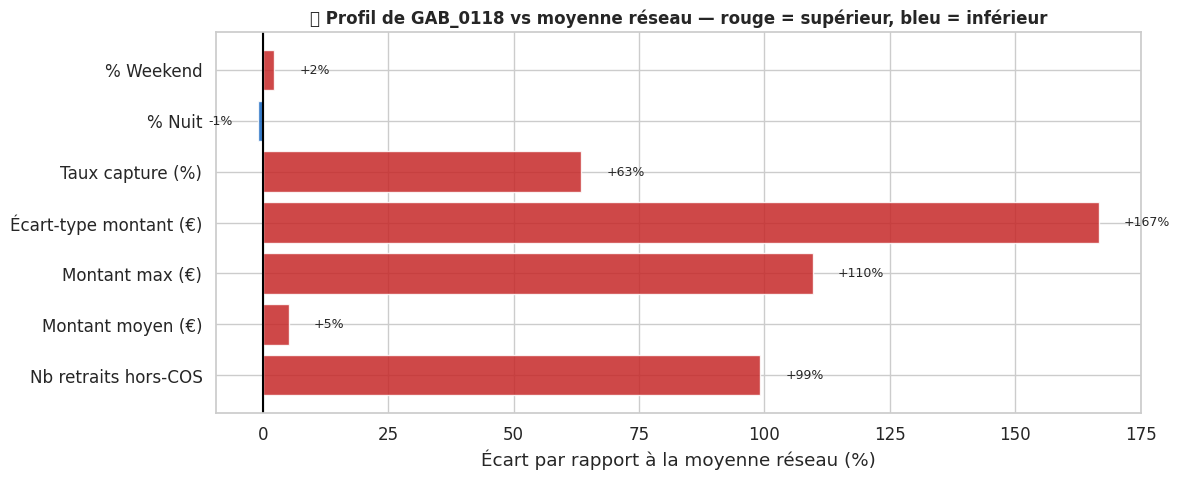


📋 Interprétation métier de GAB_0118 :
   → Taux de capture    : 1.5%  (réseau : 0.6%)
   → Montant moyen      : 227 €  (réseau : 159 €)
   → Activité nocturne  : 13.4%  (réseau : 10.5%)


In [24]:
# ── 9.2 Profil d'un GAB atypique vs le réseau ───────────────────────────────
gab_anomalie = df[df['est_anomalie']==1].nlargest(1,'score_risque').iloc[0]
gab_id = gab_anomalie['num_automate']

# Features de comparaison — on utilise les montants en €
FEATS_COMPARE = [f for f in [
    'ret_nb_horscos','ret_montant_moyen_eur','ret_montant_max_eur',
    'ret_montant_stddev_eur','taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
] if f in df.columns]

moyennes_normaux = df[df['est_anomalie']==0][FEATS_COMPARE].mean()
valeurs_anomalie = df[df['num_automate']==gab_id][FEATS_COMPARE].mean()
ecarts = ((valeurs_anomalie - moyennes_normaux) / (moyennes_normaux + 1e-9) * 100).clip(-200, 500)

labels_fr = {
    'ret_nb_horscos':       'Nb retraits hors-COS',
    'ret_montant_moyen_eur':'Montant moyen (€)',
    'ret_montant_max_eur':  'Montant max (€)',
    'ret_montant_stddev_eur':'Écart-type montant (€)',
    'taux_capture_pct':     'Taux capture (%)',
    'ret_pct_nuit':         '% Nuit',
    'ret_pct_weekend':      '% Weekend',
}

fig, ax = plt.subplots(figsize=(12, 5))
couleurs_b = [COULEUR_ANOMALIE if v > 0 else COULEUR_NORMAL for v in ecarts.values]
bars = ax.barh([labels_fr.get(c,c) for c in ecarts.index],
               ecarts.values, color=couleurs_b, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Écart par rapport à la moyenne réseau (%)')
ax.set_title(f'🔍 Profil de {gab_id} vs moyenne réseau — rouge = supérieur, bleu = inférieur',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, ecarts.values):
    x = bar.get_width()
    ax.text(x+(5 if x>=0 else -5), bar.get_y()+bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha='left' if x>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('profil_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

tc_moy = moyennes_normaux.get('taux_capture_pct', 0)
mm_moy = moyennes_normaux.get('ret_montant_moyen_eur', 0)
pn_moy = moyennes_normaux.get('ret_pct_nuit', 0)
print(f'\n📋 Interprétation métier de {gab_id} :')
if 'taux_capture_pct' in gab_anomalie:
    print(f'   → Taux de capture    : {gab_anomalie["taux_capture_pct"]:.1f}%  (réseau : {tc_moy:.1f}%)')
if 'ret_montant_moyen_eur' in gab_anomalie:
    print(f'   → Montant moyen      : {gab_anomalie["ret_montant_moyen_eur"]:.0f} €  (réseau : {mm_moy:.0f} €)')
if 'ret_pct_nuit' in gab_anomalie:
    print(f'   → Activité nocturne  : {gab_anomalie["ret_pct_nuit"]:.1f}%  (réseau : {pn_moy:.1f}%)')


In [25]:
# ── 9.3 Radar chart : comparaison GAB atypique vs réseau ──────────────────────
categories = ['Nb retraits', 'Montant moyen', 'Taux capture',
              '% Nuit', '% Weekend', 'Ratio capture']
cols_radar  = ['ret_nb','ret_montant_moyen','taux_capture_pct',
               'ret_pct_nuit','ret_pct_weekend','ratio_capture']

# Normalisation min-max pour le radar
def normaliser_radar(valeurs, ref_min, ref_max):
    return [(v - mn) / (mx - mn + 1e-9) for v, mn, mx in zip(valeurs, ref_min, ref_max)]

ref_min = df[cols_radar].quantile(0.05).values
ref_max = df[cols_radar].quantile(0.95).values

vals_anomalie = normaliser_radar(df[df['num_automate']==gab_id][cols_radar].mean().values, ref_min, ref_max)
vals_normal   = normaliser_radar(df[df['est_anomalie']==0][cols_radar].mean().values, ref_min, ref_max)

fig_radar = go.Figure()
for vals, nom, couleur in [
    (vals_anomalie, f'{gab_id} (Atypique)', COULEUR_ANOMALIE),
    (vals_normal,   'Moyenne réseau (Normal)', COULEUR_NORMAL),
]:
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=categories + [categories[0]],
        fill='toself',
        name=nom,
        line_color=couleur,
        fillcolor=couleur,
        opacity=0.35
    ))

fig_radar.update_layout(
    polar={'radialaxis': {'visible': True, 'range': [0, 1]}},
    title=f'Radar — {gab_id} vs Moyenne réseau',
    height=500
)
fig_radar.show()
print('💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.')

💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.


In [26]:
# ── 9.4 Carte des anomalies détectées ─────────────────────────────────────────
df_geo2 = df.groupby('num_automate').agg(
    longitude     = ('longitude',    'first'),
    latitude      = ('latitude',     'first'),
    score_risque  = ('score_risque', 'mean'),
    est_anomalie  = ('est_anomalie', 'max'),
    ret_nb_moyen  = ('ret_nb',       'mean'),
    taux_capture  = ('taux_capture_pct','mean'),
).reset_index()

df_geo2['statut'] = df_geo2['est_anomalie'].map({0: 'Normal', 1: 'Atypique'})

fig_anom_map = px.scatter_mapbox(
    df_geo2,
    lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'Normal': COULEUR_NORMAL, 'Atypique': COULEUR_ANOMALIE},
    size='score_risque',
    size_max=18,
    hover_name='num_automate',
    hover_data={'taux_capture': ':.2f', 'ret_nb_moyen': ':.0f', 'score_risque': ':.3f'},
    zoom=5,
    center={'lat': 46.8, 'lon': 2.3},
    mapbox_style='carto-positron',
    title='🗺️ GAB Normaux vs Atypiques — Vue géographique',
    height=550
)
fig_anom_map.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig_anom_map.show()

## 9bis. 🏷️ Raison d'atypisme & Vue consolidée annuelle

### Un GAB ne doit apparaître qu'une seule fois

L'analyse mensuelle peut faire apparaître le même GAB plusieurs fois.  
Ici on consolide : **1 ligne par GAB**, avec le nombre de mois atypiques, la raison principale, et le cluster associé.


In [27]:
# ── 9bis.1 Génération de la raison d'atypisme en langage métier ──────────────
moy_ref = df[df['est_anomalie']==0].agg({
    'taux_capture_pct':       'mean',
    'ret_pct_nuit':           'mean',
    'ret_pct_weekend':        'mean',
    'ret_montant_moyen':      'mean',
    'ret_nb_horscos':         'mean',
    'pct_reseaux_etrangers':  'mean',
}).to_dict()

def generer_raison(row, moy):
    signaux = []
    checks = [
        ('taux_capture_pct',      'Taux de capture hors-COS élevé',         True,  0.5),
        ('ret_pct_nuit',          'Activité nocturne anormalement élevée',   True,  0.5),
        ('ret_pct_weekend',       'Activité weekend anormalement élevée',    True,  0.4),
        ('pct_reseaux_etrangers', 'Fort trafic sur réseaux étrangers',       True,  1.0),
        ('ret_montant_moyen',     'Montant moyen de retrait élevé',          True,  0.5),
        ('ret_nb_horscos',        'Volume de retraits élevé',                True,  0.5),
        ('ret_nb_horscos',        'Volume de retraits faible (panne ?)',      False, 0.5),
    ]
    for col, label, positif, seuil in checks:
        if col not in row.index or col not in moy or moy[col] == 0:
            continue
        ecart = (row[col] - moy[col]) / moy[col]
        if positif and ecart > seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy[col]:.1f})')
        elif not positif and ecart < -seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy[col]:.1f})')
    if not signaux:
        signaux.append('Combinaison de signaux faibles')
    return signaux[0], ' | '.join(signaux[:3])

res = df[df['est_anomalie']==1].apply(
    lambda r: generer_raison(r, moy_ref), axis=1)
df.loc[df['est_anomalie']==1, 'raison_principale'] = [r[0] for r in res]
df.loc[df['est_anomalie']==1, 'detail_atypisme']   = [r[1] for r in res]

# ── 9bis.2 Vue annuelle consolidée — 1 ligne par GAB ─────────────────────────
agg_dict = {
    'ret_nb_horscos':     'sum',
    'ret_montant_moyen':  'mean',
    'taux_capture_pct':   'mean',
    'ret_pct_nuit':       'mean',
    'ret_pct_weekend':    'mean',
    'pct_reseaux_etrangers':'mean',
    'flag_atypique':      ['sum', 'count'],
    'est_anomalie':       'max',
    'score_risque':       'max',
    'cluster_nom':        'first',
    'type_gab_e_i':       'first',
    'longitude':          'first',
    'latitude':           'first',
}
if 'region' in df.columns:
    agg_dict['region'] = 'first'
if 'type_zone' in df.columns:
    agg_dict['type_zone'] = 'first'

df_annuel = df.groupby('num_automate').agg(agg_dict).reset_index()
df_annuel.columns = ['_'.join(c).strip('_') if isinstance(c,tuple) else c
                     for c in df_annuel.columns]

rename_map = {
    'flag_atypique_sum':   'nb_mois_atypiques',
    'flag_atypique_count': 'nb_mois_actifs',
    'ret_nb_horscos_sum':  'ret_nb_annuel',
    'ret_montant_moyen_mean':'ret_montant_moyen',
    'taux_capture_pct_mean': 'taux_capture_moyen',
    'ret_pct_nuit_mean':     'pct_nuit_moyen',
    'ret_pct_weekend_mean':  'pct_weekend_moyen',
    'pct_reseaux_etrangers_mean':'pct_etranger_moyen',
    'est_anomalie_max':      'est_anomalie',
    'score_risque_max':      'score_risque',
    'cluster_nom_first':     'cluster_nom',
    'type_gab_e_i_first':    'type_gab_e_i',
    'longitude_first':       'longitude',
    'latitude_first':        'latitude',
}
if 'region_first' in df_annuel.columns:
    rename_map['region_first'] = 'region'
if 'type_zone_first' in df_annuel.columns:
    rename_map['type_zone_first'] = 'type_zone'

df_annuel = df_annuel.rename(columns=rename_map)
df_annuel['pct_mois_atypiques'] = (
    df_annuel['nb_mois_atypiques'] / df_annuel['nb_mois_actifs'] * 100).round(1)

# Raison principale sur les mois atypiques
raison_par_gab = (df[df['est_anomalie']==1]
                    .groupby('num_automate')['raison_principale']
                    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'N/A'))
df_annuel['raison_principale'] = df_annuel['num_automate'].map(raison_par_gab).fillna('—')

# Catégorie de risque
df_annuel['categorie_risque'] = pd.cut(
    df_annuel['nb_mois_atypiques'],
    bins=[-1, 0, 2, 5, 100],
    labels=['🟢 Normal', '🟡 Modéré (1-2 mois)',
            '🟠 Élevé (3-5 mois)', '🔴 Critique (6+ mois)']
)

nb_atypiques = (df_annuel['nb_mois_atypiques'] > 0).sum()
print(f'📋 Vue annuelle consolidée : {len(df_annuel)} GAB uniques')
print(f'   🔴 GAB avec au moins 1 mois atypique : {nb_atypiques}')
print(f'   🟢 GAB sans aucun mois atypique       : {len(df_annuel)-nb_atypiques}')
print()
print(df_annuel['categorie_risque'].value_counts().sort_index().to_string())


📋 Vue annuelle consolidée : 120 GAB uniques
   🔴 GAB avec au moins 1 mois atypique : 12
   🟢 GAB sans aucun mois atypique       : 108

categorie_risque
🟢 Normal                108
🟡 Modéré (1-2 mois)       0
🟠 Élevé (3-5 mois)        0
🔴 Critique (6+ mois)     12


In [28]:
# ── 9bis.3 Table de synthèse annuelle enrichie ────────────────────────────────
cols_affichage = ['num_automate','nb_mois_atypiques','pct_mois_atypiques',
                  'categorie_risque','score_risque','cluster_nom','raison_principale',
                  'taux_capture_moyen','pct_nuit_moyen','pct_etranger_moyen']
cols_affichage = [c for c in cols_affichage if c in df_annuel.columns]

top_annuel = (df_annuel[df_annuel['nb_mois_atypiques']>0]
              .sort_values(['nb_mois_atypiques','score_risque'], ascending=[False,False])
              [cols_affichage].reset_index(drop=True))
top_annuel.index += 1

print(f'🏧 Top GAB atypiques — vue annuelle ({len(top_annuel)} GAB) :')
display(top_annuel.head(20).style
    .background_gradient(subset=['nb_mois_atypiques'], cmap='YlOrRd')
    .background_gradient(subset=['score_risque'],       cmap='Reds')
    .format({c: '{:.1f}' for c in ['pct_mois_atypiques','taux_capture_moyen',
                                    'pct_nuit_moyen','pct_etranger_moyen',
                                    'score_risque'] if c in top_annuel.columns}))


🏧 Top GAB atypiques — vue annuelle (12 GAB) :


,num_automate,nb_mois_atypiques,pct_mois_atypiques,categorie_risque,score_risque,cluster_nom,raison_principale,taux_capture_moyen,pct_nuit_moyen,pct_etranger_moyen
1,GAB_0118,24,100.0,🔴 Critique (6+ mois),1.0,🌍 Dominante étrangère,Taux de capture hors-COS élevé (1.0 vs moy. 0.6),0.9,10.4,22.5
2,GAB_0114,24,100.0,🔴 Critique (6+ mois),0.9,🌍 Dominante étrangère,Taux de capture hors-COS élevé (0.9 vs moy. 0.6),0.9,11.7,24.5
3,GAB_0110,24,100.0,🔴 Critique (6+ mois),0.9,🌍 Dominante étrangère,Taux de capture hors-COS élevé (0.9 vs moy. 0.6),0.9,10.5,22.0
4,GAB_0113,24,100.0,🔴 Critique (6+ mois),0.8,🌙 Nocturnes,Activité nocturne anormalement élevée (50.4 vs moy. 10.5),1.0,43.0,1.1
5,GAB_0112,24,100.0,🔴 Critique (6+ mois),0.8,🌍 Dominante étrangère,Taux de capture hors-COS élevé (10.3 vs moy. 0.6),9.4,13.3,2.4
6,GAB_0116,24,100.0,🔴 Critique (6+ mois),0.8,🌍 Dominante étrangère,Taux de capture hors-COS élevé (10.8 vs moy. 0.6),9.8,12.5,2.3
7,GAB_0108,24,100.0,🔴 Critique (6+ mois),0.7,🌆 Urbains standard,Taux de capture hors-COS élevé (9.4 vs moy. 0.6),9.6,12.2,2.6
8,GAB_0109,24,100.0,🔴 Critique (6+ mois),0.7,🌙 Nocturnes,Taux de capture hors-COS élevé (1.3 vs moy. 0.6),1.1,39.6,1.0
9,GAB_0117,24,100.0,🔴 Critique (6+ mois),0.7,🌙 Nocturnes,Taux de capture hors-COS élevé (1.4 vs moy. 0.6),0.9,43.4,1.1
10,GAB_0119,24,100.0,🔴 Critique (6+ mois),0.6,🟢 Standard,—,0.7,12.0,1.2


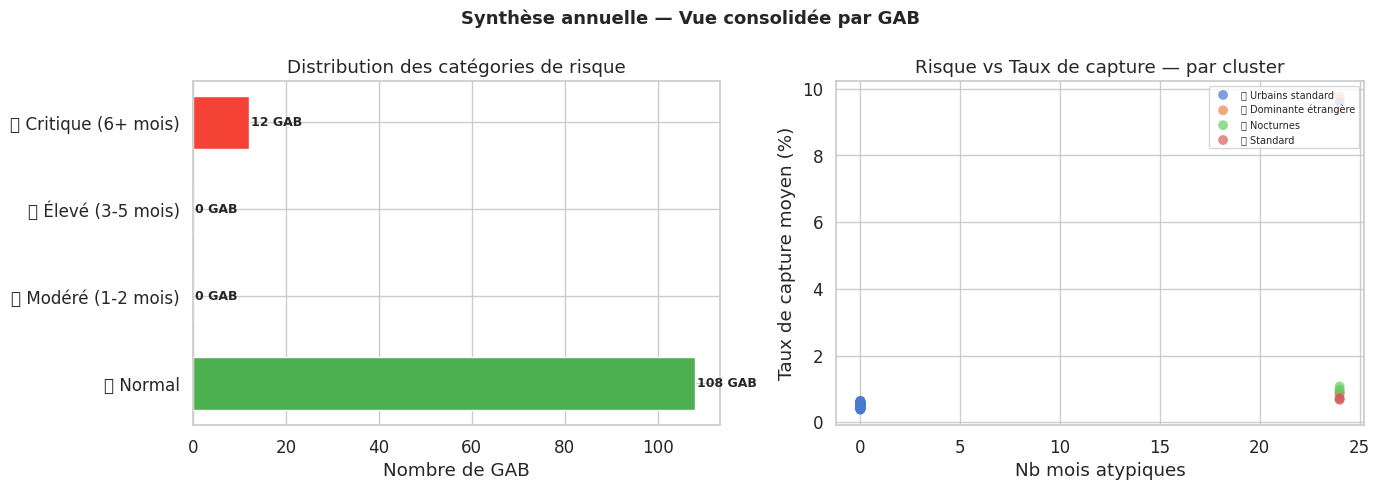

In [29]:
# ── 9bis.4 Graphique synthèse annuelle ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthèse annuelle — Vue consolidée par GAB', fontsize=13, fontweight='bold')

# Gauche : distribution des catégories de risque
ax1 = axes[0]
cat_counts = df_annuel['categorie_risque'].value_counts().sort_index()
bar_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336'][:len(cat_counts)]
bars = ax1.barh(cat_counts.index.astype(str), cat_counts.values,
                color=bar_colors, edgecolor='white', height=0.6)
ax1.set_title('Distribution des catégories de risque')
ax1.set_xlabel('Nombre de GAB')
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val} GAB', va='center', fontsize=9, fontweight='bold')

# Droite : scatter nb_mois_atypiques vs taux_capture coloré par cluster
ax2 = axes[1]
for cid in sorted(df_annuel['cluster_nom'].unique()):
    mask = df_annuel['cluster_nom'] == cid
    cid_num = df_annuel.loc[mask,'cluster_nom'].index[0] % len(PALETTE_CLUSTERS)
    ax2.scatter(df_annuel.loc[mask,'nb_mois_atypiques'],
                df_annuel.loc[mask,'taux_capture_moyen'],
                label=cid, alpha=0.7, s=50, edgecolors='none')
ax2.set_xlabel('Nb mois atypiques')
ax2.set_ylabel('Taux de capture moyen (%)')
ax2.set_title('Risque vs Taux de capture — par cluster')
ax2.legend(fontsize=7, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('synthese_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. ✅ Validation du Modèle

### Comment évaluer un modèle sans étiquettes ?

Sans vérité terrain, nous utilisons 3 méthodes de validation alternatives :

1. **Validation statistique** : les anomalies détectées sont-elles vraiment aux extrêmes des distributions ?
2. **Analyse des cas extrêmes** : les GAB avec z-score > 3 sont-ils bien détectés ?
3. **Plausibilité métier** : les explications correspondent-elles à des situations connues ?

In [ ]:
# ── 10.1 Validation statistique ───────────────────────────────────────────────
print('📊 Comparaison statistique : Normaux vs Atypiques')
print('=' * 65)

stats_comp = df.groupby('est_anomalie')[[
    'ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit'
]].mean().round(2)

stats_comp.index = ['🟢 Normaux', '🔴 Atypiques']
stats_comp.columns = ['Nb retraits', 'Montant moyen (€)', 'Taux capture (%)', '% Nuit']

print(stats_comp.to_string())
print()

# Ratios
ratios = (stats_comp.loc['🔴 Atypiques'] / stats_comp.loc['🟢 Normaux']).round(2)
print('📈 Ratios Atypiques / Normaux :')
for col, ratio in ratios.items():
    indicateur = '🔴 Anormal' if ratio > 1.5 or ratio < 0.5 else '🟡 Notable' if ratio > 1.2 else '🟢 Proche'
    print(f'   {indicateur}  {col} : ×{ratio}')

📊 Comparaison statistique : Normaux vs Atypiques
             Nb retraits  Montant moyen (€)  Taux capture (%)  % Nuit
🟢 Normaux         622.47           15867.34              0.58   10.51
🔴 Atypiques       713.21           16474.04              4.16   17.93

📈 Ratios Atypiques / Normaux :
   🟢 Proche  Nb retraits : ×1.15
   🟢 Proche  Montant moyen (€) : ×1.04
   🔴 Anormal  Taux capture (%) : ×7.17
   🔴 Anormal  % Nuit : ×1.71


In [ ]:
# ── 10.2 Validation par z-scores (règle des 3σ) ───────────────────────────────
cols_zscore = ['ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit']

for col in cols_zscore:
    mu  = df[col].mean()
    sig = df[col].std()
    df[f'zscore_{col}'] = (df[col] - mu) / (sig + 1e-9)

df['nb_zscore_extreme'] = sum(
    (df[f'zscore_{c}'].abs() > 3).astype(int) for c in cols_zscore
)

# Taux de détection croisée
detectes_zscore    = df[df['nb_zscore_extreme'] >= 1]['est_anomalie'].mean()
non_detectes_model = df[(df['est_anomalie']==1) & (df['nb_zscore_extreme']==0)].shape[0]

print(f'🔬 Validation croisée :')
print(f'   → {detectes_zscore*100:.1f}% des cas extrêmes (z>3) sont classés atypiques par le modèle')
print(f'   → {non_detectes_model} anomalies détectées par le modèle MAIS non visibles par z-score simple')
print(f'     (→ ce sont les anomalies subtiles, invisibles à l\'œil nu 🎯)')

🔬 Validation croisée :
   → 37.7% des cas extrêmes (z>3) sont classés atypiques par le modèle
   → 99 anomalies détectées par le modèle MAIS non visibles par z-score simple
     (→ ce sont les anomalies subtiles, invisibles à l'œil nu 🎯)


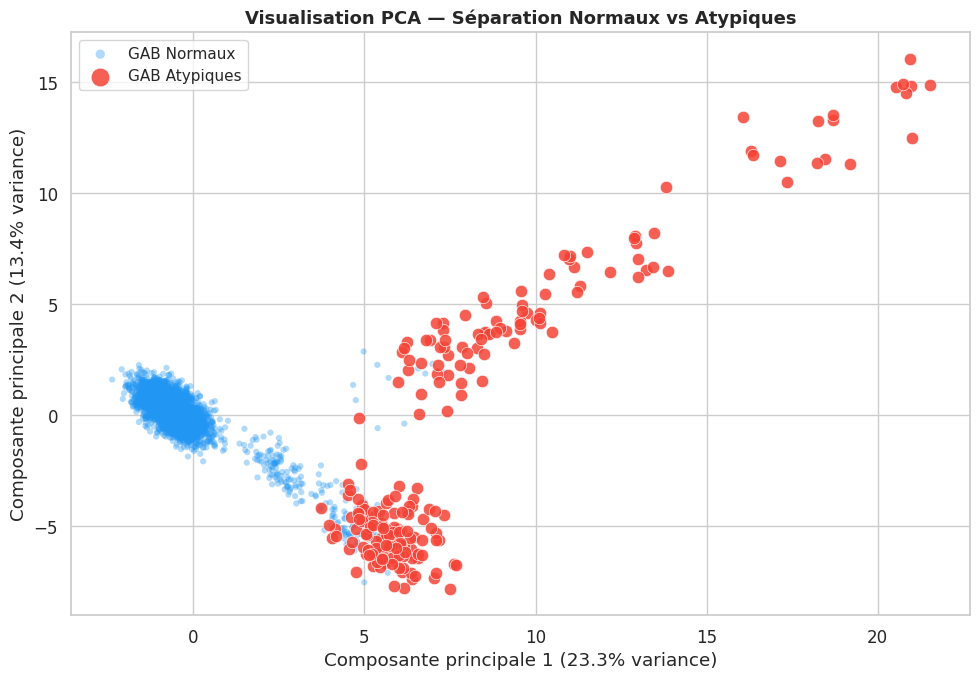

💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.


In [ ]:
# ── 10.3 Réduction dimensionnelle PCA pour visualisation ──────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

for label, mask, couleur, taille, alpha in [
    ('GAB Normaux',   df['est_anomalie']==0, COULEUR_NORMAL,   20, 0.35),
    ('GAB Atypiques', df['est_anomalie']==1, COULEUR_ANOMALIE, 80, 0.85),
]:
    ax.scatter(df[mask]['pca1'], df[mask]['pca2'],
               c=couleur, s=taille, alpha=alpha, label=label,
               edgecolors='white' if taille > 30 else 'none', linewidths=0.5)

ax.set_xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Visualisation PCA — Séparation Normaux vs Atypiques', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=11)

plt.tight_layout()
plt.savefig('pca_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.')

## 11. 📖 Synthèse — Ce que le Modèle a Découvert

### Conclusions pour les équipes métier

In [ ]:
# ── 11.1 Tableau de bord synthèse ─────────────────────────────────────────────
n_total     = len(df)
n_anom      = df['est_anomalie'].sum()
n_normal_d  = n_total - n_anom
score_moy   = df[df['est_anomalie']==1]['score_risque'].mean()

print('=' * 60)
print('  📋 SYNTHÈSE — DÉTECTION D\'ANOMALIES GAB')
print('=' * 60)
print(f'  🏧 Total automates analysés      : {n_total}')
print(f'  🟢 GAB au comportement normal    : {n_normal_d} ({n_normal_d/n_total*100:.1f}%)')
print(f'  🔴 GAB au comportement atypique  : {n_anom} ({n_anom/n_total*100:.1f}%)')
print(f'  📊 Score de risque moyen (atyp.) : {score_moy:.3f} / 1.000')
print('=' * 60)
print()
print('  COMPORTEMENT NORMAL DU RÉSEAU :')
normaux = df[df['est_anomalie']==0]
print(f'  • Volume moyen      : {normaux["ret_nb"].mean():.0f} retraits/mois')
print(f'  • Montant moyen     : {normaux["ret_montant_moyen"].mean():.0f} €')
print(f'  • Taux capture moy. : {normaux["taux_capture_pct"].mean():.2f}%')
print(f'  • Activité nocturne : {normaux["ret_pct_nuit"].mean():.1f}%')
print()
print('  SIGNAUX D\'ALERTE LES PLUS FRÉQUENTS :')
print('  🔴 Taux de capture anormalement élevé (fraude / panne)')
print('  🔴 Montants moyens hors norme (opérations inhabituelles)')
print('  🔴 Activité nocturne excessive (comportement suspect)')
print('  🔴 Concentration réseau atypique (anomalie de flux cartes)')
print('=' * 60)

  📋 SYNTHÈSE — DÉTECTION D'ANOMALIES GAB
  🏧 Total automates analysés      : 4320
  🟢 GAB au comportement normal    : 4104 (95.0%)
  🔴 GAB au comportement atypique  : 216 (5.0%)
  📊 Score de risque moyen (atyp.) : 0.688 / 1.000

  COMPORTEMENT NORMAL DU RÉSEAU :
  • Volume moyen      : 622 retraits/mois
  • Montant moyen     : 15867 €
  • Taux capture moy. : 0.58%
  • Activité nocturne : 10.5%

  SIGNAUX D'ALERTE LES PLUS FRÉQUENTS :
  🔴 Taux de capture anormalement élevé (fraude / panne)
  🔴 Montants moyens hors norme (opérations inhabituelles)
  🔴 Activité nocturne excessive (comportement suspect)
  🔴 Concentration réseau atypique (anomalie de flux cartes)


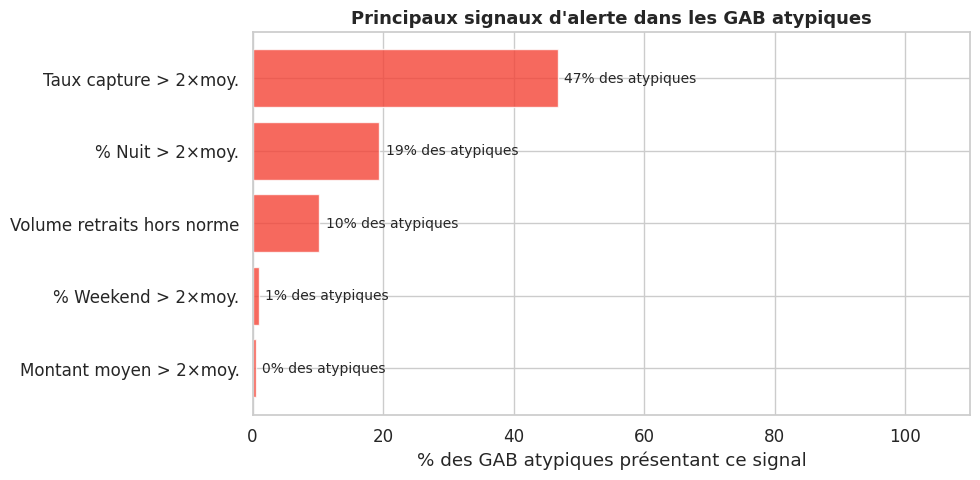

In [ ]:
# ── 11.2 Graphique final : les signaux d'alerte par fréquence ─────────────────
anom_df = df[df['est_anomalie']==1]
norm_df = df[df['est_anomalie']==0]

signaux = {
    'Taux capture > 2×moy.':       (anom_df['taux_capture_pct']   > norm_df['taux_capture_pct'].mean()*2).mean()*100,
    'Montant moyen > 2×moy.':      (anom_df['ret_montant_moyen']  > norm_df['ret_montant_moyen'].mean()*2).mean()*100,
    '% Nuit > 2×moy.':             (anom_df['ret_pct_nuit']       > norm_df['ret_pct_nuit'].mean()*2).mean()*100,
    '% Weekend > 2×moy.':          (anom_df['ret_pct_weekend']    > norm_df['ret_pct_weekend'].mean()*2).mean()*100,
    'Volume retraits hors norme':   (anom_df['ret_nb'].abs()       > norm_df['ret_nb'].mean()*2).mean()*100,
}

signaux_series = pd.Series(signaux).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(signaux_series.index, signaux_series.values,
               color=COULEUR_ANOMALIE, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, signaux_series.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}% des atypiques', va='center', fontsize=10)

ax.set_xlabel('% des GAB atypiques présentant ce signal')
ax.set_title('Principaux signaux d\'alerte dans les GAB atypiques', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('signaux_alerte.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 11.3 Export de la liste des GAB à investiguer ─────────────────────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'
liste_investigation = df[df['est_anomalie']==1][
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i',cp_col ]
].sort_values('score_risque', ascending=False).reset_index(drop=True)

liste_investigation.index += 1

# Décommenter pour exporter
# liste_investigation.to_csv('gab_a_investiguer.csv', index=True)
# print('✅ Fichier exporté : gab_a_investiguer.csv')

print(f'📋 {len(liste_investigation)} GAB recommandés pour investigation :')
display(liste_investigation.head(15).style
    .background_gradient(subset=['score_risque'], cmap='Reds')
    .format({'score_risque': '{:.3f}', 'taux_capture_pct': '{:.2f}',
             'ret_montant_moyen': '{:.0f}'}))

📋 216 GAB recommandés pour investigation :


,num_automate,score_risque,ret_nb,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,type_gab_e_i,code_postale_emplacement
1,GAB_0118,1.000,1522,22702,1.46,13.373929,25.039119,Externe,75001
2,GAB_0114,0.962,344,11359,1.25,12.033141,18.114385,Externe,97300
3,GAB_0118,0.944,1485,18569,0.92,9.458762,16.527143,Externe,75001
4,GAB_0118,0.925,322,14468,0.81,10.247283,20.481043,Externe,97400
5,GAB_0110,0.920,341,12859,1.00,11.871447,24.280239,Externe,97150
6,GAB_0114,0.915,1015,14089,1.28,15.302743,36.224940,Interne,59000
7,GAB_0114,0.905,841,11075,0.69,15.942250,20.193673,Interne,59000
8,GAB_0110,0.904,384,17831,0.79,10.481427,24.480197,Externe,97100
9,GAB_0114,0.904,1015,17615,0.98,8.814639,21.922312,Externe,59000
10,GAB_0110,0.903,400,12260,0.77,13.550593,21.776580,Externe,97400


## 12. 📌 Conclusion & Recommandations

---

### Ce que le modèle apporte

| Ce que vous faisiez avant | Ce que le modèle permet maintenant |
|---|---|
| Surveillance manuelle par seuil | Détection automatique multi-dimensionnelle |
| Anomalies évidentes seulement | Détection de signaux faibles combinés |
| Analyse rétrospective | Alerte mensuelle systématique |
| Subjectif / expertise individuelle | Reproductible et documenté |

---

### Prochaines étapes recommandées

1. **Validation métier** : soumettre la liste des GAB détectés aux experts pour qualification (vrai/faux positif)
2. **Enrichissement** : intégrer des données de contexte (incidents déclarés, interventions techniques)
3. **Mise en production** : exécution mensuelle automatique dans Dataiku
4. **Amélioration continue** : avec les retours métier, passer progressivement à un modèle semi-supervisé

---

> *« Un modèle n'est pas là pour remplacer l'expertise métier, mais pour l'amplifier.  
> Il voit ce que l'œil ne peut pas voir sur 500 automates simultanément. »*

---